# MAGI version 0.8.1 — corrected line truth and gate supervision

v0.8.1 keeps v0.8's architecture unchanged — `CVAE_MixEnergy_ContPhi_TaskAdaptive`:
a conditional RQS-flow continuum with a CDF pre-warp, plus fixed-position Gaussian
lines pinned to the X-IFU 4 eV FWHM, energy head and gate conditioned on the latent
`z`, and a learnable conditional coupling prior `p(z|cond)`. What changes is
everything *around* the model: what it is told the lines are, how its gate is
supervised, and how it is measured.

Four defects were found and fixed (full account, with the numbers, in
`docs/v0.8.1_line_truth.md`):

| | Defect in v0.8 | Fix in v0.8.1 |
|---|---|---|
| **A** | `recovery_ratio = n_gen/n_real` never normalized for sample size, while generation was capped at 1e6 against 3.44e6 / 1.87e6 real events | metric normalizes by `N_real/N_gen`; validation generates to the real count |
| **B** | the recovery window was 2 detection bins — ±750 eV at 8.9 keV, **190× the pinned 4 eV line** — so it measured continuum, and adjacent lines' windows overlapped | resolution-scaled window (±5σ) with side-band continuum subtraction and an overlap flag |
| **C** | the candidate table came from Geant4's `fluor_Bearden`, but the simulation emitted the **EADL** energies — every fluorescence line was pinned **4–11 FWHM** from its real peak, and a list-order-greedy matcher labelled CR's Cu Kα peak "Ni Kβ" | table rebuilt from EADL, closest-pair matching, and sub-bin peak refinement before matching |
| **D** | gate targets were Gaussian-soft over the *bin* width — **±43 keV at 511 keV** — labelling 3.5–4.6× too many events as line events | `bandwidth_mode="resolution"`: bandwidth from the pinned line width (labels 0.98× the true line fraction) |

Measured consequence of A–C: what v0.8 reported as "CR 511 = 0.85, Small lines
excellent" was really **511 over-generated 5.8×**, with **zero real events** at the
energy three of the four CR lines were pinned to.

**What is different from `MAGI_v0_8.ipynb`**

- the EADL candidate table + peak refinement in the detection cell;
- a new **line-position audit** section that measures every line's centroid and
  width straight from the raw events, in eV, before anything is trained;
- resolution-driven gate targets, with a diagnostic comparing the labelling of both
  modes against the true line fractions;
- `gate_focal_gamma = 1` (down from 2 — with the labels no longer inflated, γ=2
  over-boosts and digs the continuum beside the lines);
- validation on the corrected metric plus a compact **acceptance report**.

**Notebook layout** (same order as `MAGI_v0_7_2.ipynb`)

1. Dataset Import and Checks — load, physical features, diagnostics, energy line detection.
2. Line-position audit — where the lines really are (v0.8.1).
3. Standardization and Preprocessing — feature dataframe, gate targets, split/conditioning, CDF warp knots.
4. Training with MAGI Package.
5. Generation and Validation — acceptance report, spectra, residuals, pairgrid, covariance/correlation.
6. Saving Model.
7. Generating Input Files for Geant4.
8. Appendix — flow vs Gaussian continuum (synthetic).

**One source per run.** Set `SOURCE` to `"CR"`, `"Small"`, `"Torio"`, or
`"CR DM1.2"` and re-run; each source pairs with its own candidate-line table,
since CR/Small/Torio share the SRON cryostat GDML while DM1.2 is a different
mass model with different nearby materials (see the candidate-lines cell).
The unattended CR/Small equivalent is `tools/run_v0_8_real.py`, scored by
`tools/acceptance_v0_8.py` and `tools/plot_v0_8_real_corr.py`.

In [1]:
# ==========================================================
# Imports
# Force CPU BEFORE importing magi: tensorflow-metal is ~8-10% slower than CPU
# for this tfp op mix on the M1, and magi pulls in tensorflow_probability,
# which would otherwise initialize the Metal device - after which hiding the
# GPU no longer takes effect. (Same choice as MAGI_v0_7_2.ipynb.)
# ==========================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # reduce TensorFlow log verbosity

import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wasserstein_distance

# ==========================================================
# TensorFlow / Keras
# ==========================================================
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)
print("\nPhysical devices  :", tf.config.list_physical_devices())
print("Visible GPU(s)    :", tf.config.get_visible_devices("GPU"))

TensorFlow version: 2.16.2
Keras version     : 3.12.1

Physical devices  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Visible GPU(s)    : []


In [2]:
import magi

print(magi.__file__)
print(magi.__version__)
print(magi.CVAE_CatEnergy_ContPhi_TaskAdaptive)   # v0.7.2 head, for reference
print(magi.CVAE_MixEnergy_ContPhi_TaskAdaptive)   # v0.8 head, used here

magi.initialize_environment(seed=42, cpu_only=True)
magi.set_plot_theme("light")

/Volumes/X10Pro/MAGI/MAGI_package/magi/__init__.py
0.8.1
<class 'magi.core.model.CVAE_CatEnergy_ContPhi_TaskAdaptive'>
<class 'magi.core.model.CVAE_MixEnergy_ContPhi_TaskAdaptive'>


## Dataset Import and Checks

One file per background component (see `CLAUDE.md` for the data layout). This
notebook runs **one source at a time** — pick it below and re-run the notebook
for the other one. CR and Small (K-40) are the two sources in scope for v0.8;
the Radio/Torio (Ra-226 / Th-232) files are deferred to a later phase.

In [3]:
TRAINING_DATA_DIR = "/Volumes/X10Pro/MAGI/TrainingData"

SOURCE_FILES = {
    "CR":    f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereCR.dat",
    "Small": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereSmall.dat",
    "Torio": f"{TRAINING_DATA_DIR}/alloutputDSCryoSphereTorio.dat",
    "CR DM1.2": f"{TRAINING_DATA_DIR}/outputDSCryoSphereCRs_DM1_2.dat"
}

# ---- pick the source for this run -------------------------------------
SOURCE = "CR DM1.2"          # "CR", "Small", "Torio", or "CR DM1.2"
# -----------------------------------------------------------------------

center = (0.0, 0.0, 5.0)
R = 105.0

X_IFU_RESOLUTION_EV = 4.0   # X-IFU energy resolution (FWHM), pins the line widths

df = magi.load_detector_table(
    filepath=SOURCE_FILES[SOURCE],
    sep=r"\s+",
)

magi.report_basic_table_checks(df)

prep = magi.build_physical_features(
    df,
    center=center,
    radius=R,
)

magi.print_physical_summary(prep)

# Base diagnostic objects
feat_base = prep["features"]
raw = prep["raw"]
proj = prep["projected"]
normdir = prep["normalized_direction"]
derived = prep["derived"]

E_all = feat_base["Energy"].to_numpy()
print(f"\n{SOURCE}: {len(df):,} rows, {E_all.size:,} valid energies, "
      f"E in [{E_all.min():.6f}, {E_all.max():.4f}] MeV "
      f"({np.log10(E_all.max() / E_all.min()):.1f} decades)")

N rows: 72544
  ParticleName   Energy  PrimBool  ParticleId  ParentParticleId  \
0          mu-  839.068         1           1                 0   
1          mu-  209.450         1           1                 0   
2          mu-  141.852         1           1                 0   
3          mu-  173.347         1           1                 0   
4          mu-  135.787         1           1                 0   

  CreatorProcessName         X        Y        Z        Vx        Vy        Vz  
0            Primary   0.26916 -88.4064  61.4646 -0.017774  0.816107 -0.577628  
1            Primary  39.69970  26.2758  98.4748 -0.176732 -0.371371 -0.911509  
2            Primary  32.57540  52.1094  90.0145 -0.156074 -0.396216 -0.904795  
3            Primary  20.98390 -55.7598  91.3396 -0.252079  0.611730 -0.749829  
4            Primary  -2.20503 -58.6829  91.9221 -0.094475  0.488356 -0.867515  

NaN per column:
 ParticleName          0
Energy                0
PrimBool              0
Particl

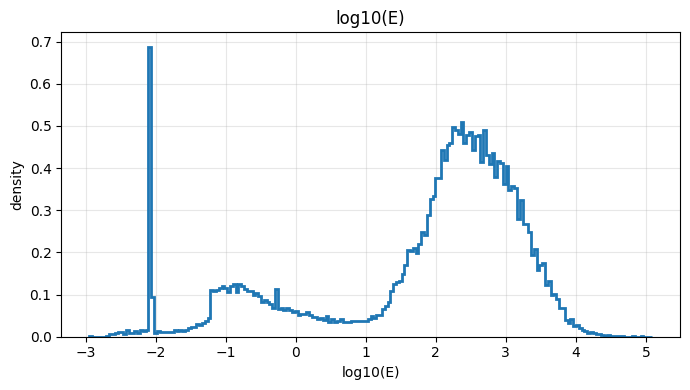

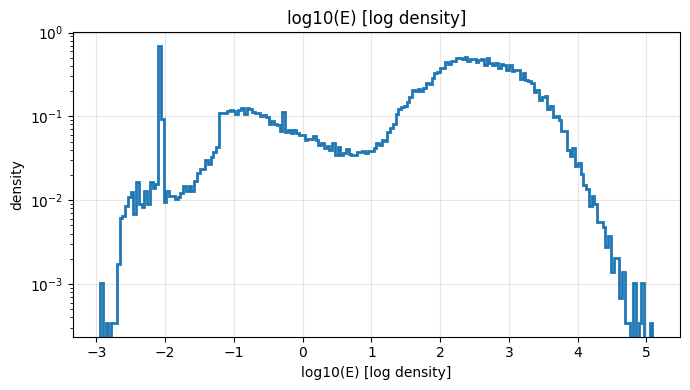

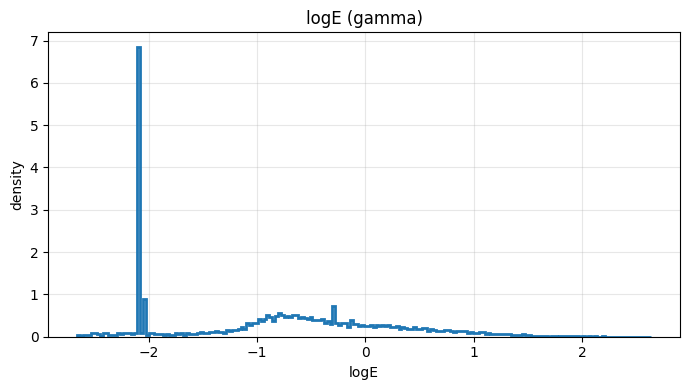

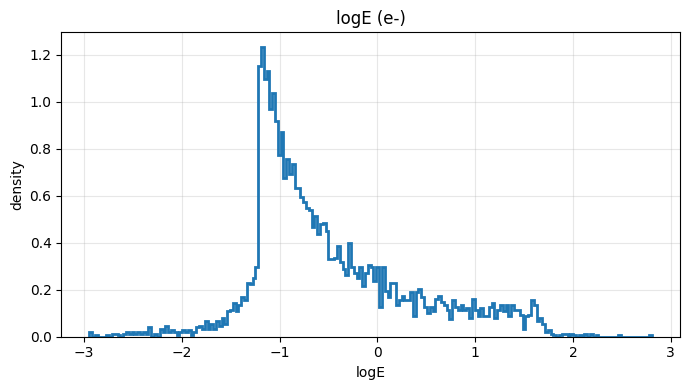

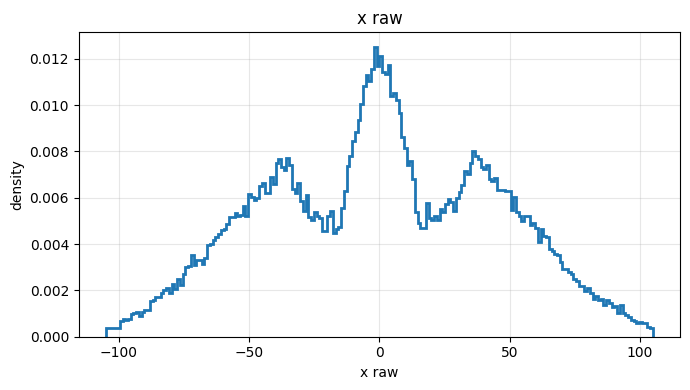

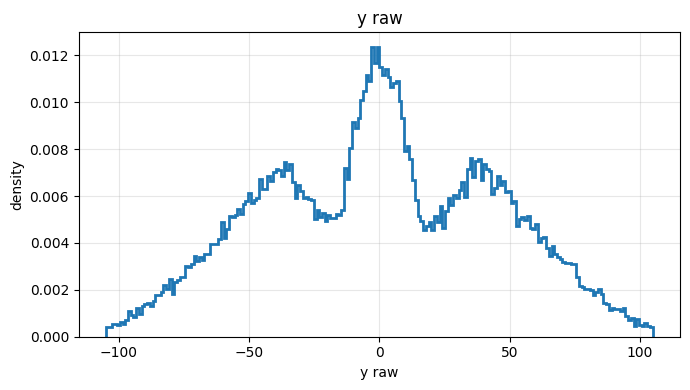

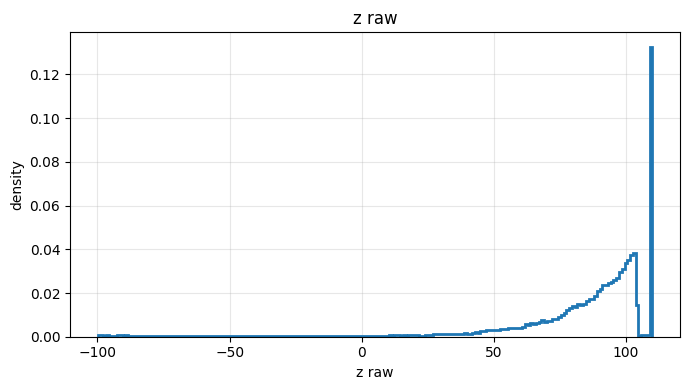

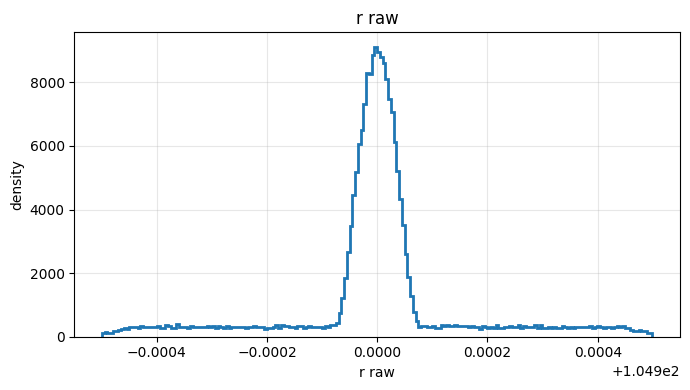

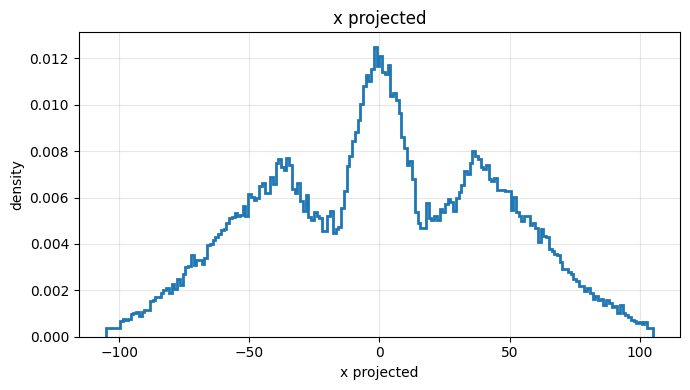

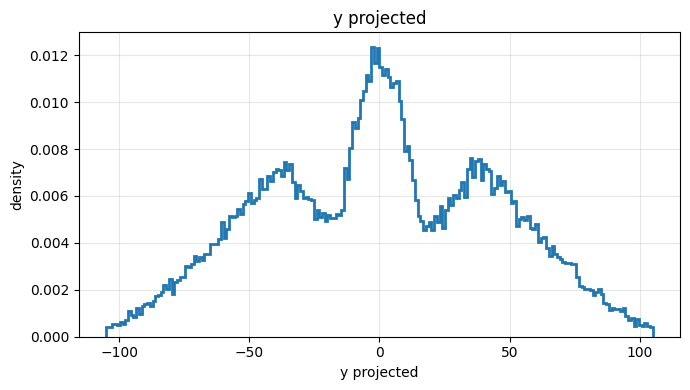

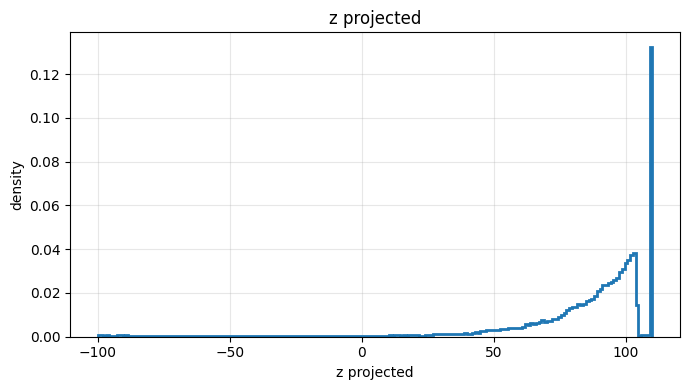

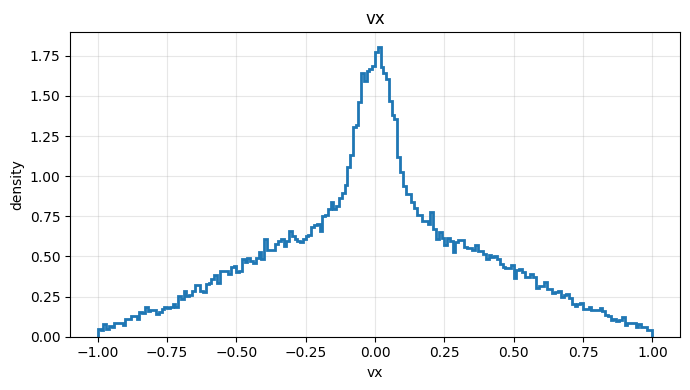

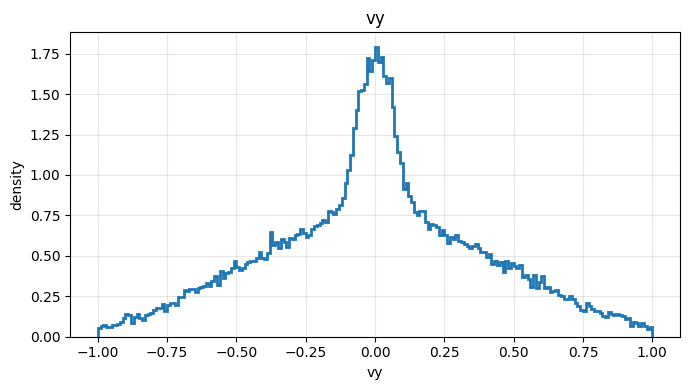

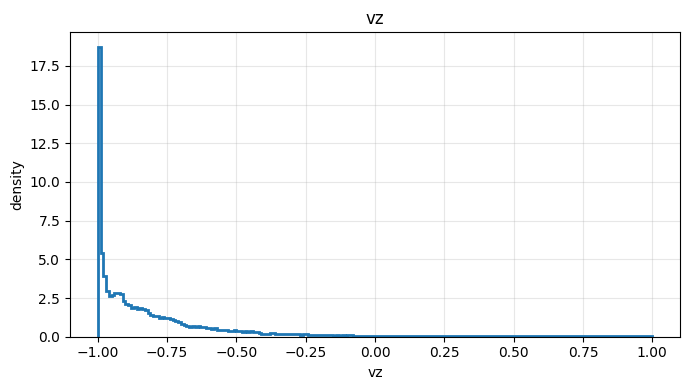

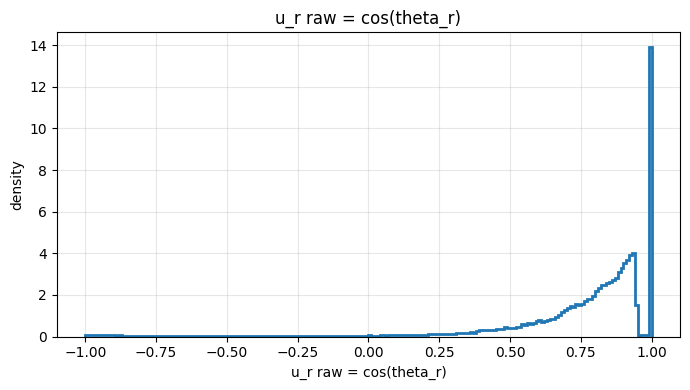

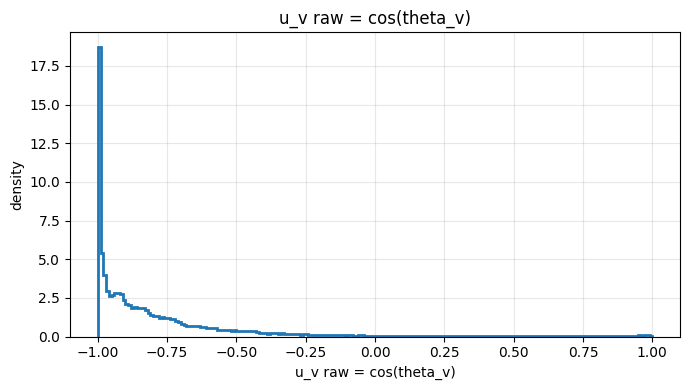

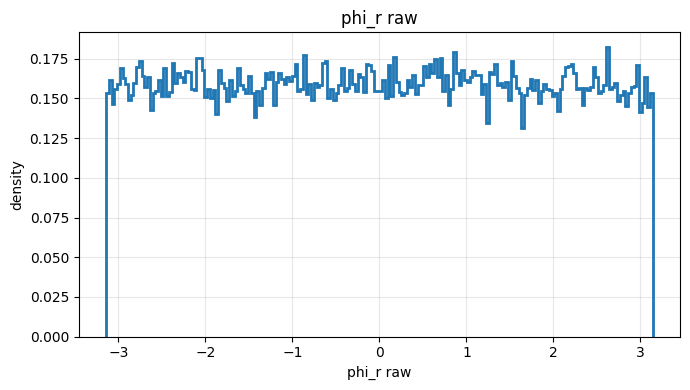

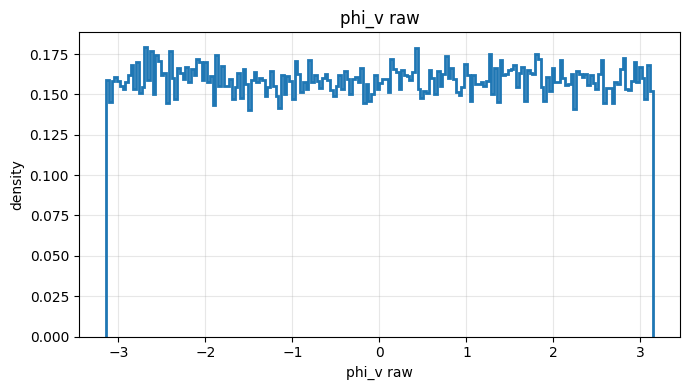

In [4]:
# ==========================================================
# Energy diagnostics from base physical features
# The v0.8 energy head models y = log10(E) directly (no binning), so the
# log-E shape below IS the target density the flow has to reproduce.
# ==========================================================

magi.plot_dist(feat_base["logE"], "log10(E)")
magi.plot_dist(feat_base["logE"], "log10(E) [log density]", yscale="log")
magi.plot_dist_by_class(feat_base, "logE", selected_class="gamma")
magi.plot_dist_by_class(feat_base, "logE", selected_class="e-")

# ==========================================================
# Raw / projected geometry
# ==========================================================

magi.plot_dist(raw["x"], "x raw")
magi.plot_dist(raw["y"], "y raw")
magi.plot_dist(raw["z"], "z raw")
magi.plot_dist(raw["r"], "r raw")

magi.plot_dist(proj["x"], "x projected")
magi.plot_dist(proj["y"], "y projected")
magi.plot_dist(proj["z"], "z projected")

magi.plot_dist(normdir["vx"], "vx")
magi.plot_dist(normdir["vy"], "vy")
magi.plot_dist(normdir["vz"], "vz")

# ==========================================================
# Raw physical geometry variables (unchanged from v0.7.2)
# ==========================================================

magi.plot_dist(feat_base["u_r"], "u_r raw = cos(theta_r)", range_=(-1, 1))
magi.plot_dist(feat_base["u_v"], "u_v raw = cos(theta_v)", range_=(-1, 1))
magi.plot_dist(feat_base["phi_r"], "phi_r raw", range_=(-np.pi, np.pi))
magi.plot_dist(feat_base["phi_v"], "phi_v raw", range_=(-np.pi, np.pi))

plt.show()

### Energy line detection

The mixture head is *told* where the lines are — their positions are fixed inputs
(`line_positions_y`), not learned — so getting them right matters more than any
tuning knob downstream. Detection matches statistically significant peaks against
the mass model's candidate table (`CandidateLines/..._EADL[_escape].json`),
built by the next cell from Geant4's own databases: the atomic-relaxation
tables for every element in the GDML mass model, and PhotonEvaporation5.2 for
the K-40 / Ra-226 / Th-232 / Rn-222 decay lines — no values hand-typed from
outside literature. The build cell caches its output, so it only re-parses the
GDML and the Geant4 databases the first time a given mass model is used.

Three v0.8.1 corrections apply here:

- **EADL energies.** The table now takes its energies from `G4EMLOW7.3/fluor`
  (what Geant4 emits by default) while keeping the transition *labels* from
  `fluor_Bearden` (the only directory that ships them). The two differ by 17–43 eV
  — 4–11 detector FWHM — and the measured peaks match EADL to <1 eV.
- **Closest-pair matching.** Candidates used to claim peaks in JSON list order, so
  CR's ~8.0 keV Cu Kα peak was taken by Ni Kβ, 194 eV away, and modelled under the
  wrong label.
- **Sub-bin peak refinement** (`refine_bin_width_mev`). A detection bin is ~166 eV
  wide at 8 keV and ~21 keV at 511 keV on CR's log grid, so its centre is not a
  usable line position — without refinement the 511 keV peak matches Po-218.

Expected: instrumental fluorescence lines appear as `matched_lines`; the source
decay lines mostly appear as `unmatched_candidates`, since the sources sit in bulk
shielding and their primary gammas are Compton-degraded before crossing the
CryoSphere.

In [5]:
# ==========================================================
# Build the candidate-lines file from the GDML mass model
#
# The candidate table is tied to a mass model, so it follows SOURCE: CR/
# Small/Torio share the SRON CCN cryostat GDML, but "CR DM1.2" is a
# different, later mass model (S1GDML_DM1.2/CriostatoDM1_2_...gdml) with
# different materials near the detector - different fluorescence lines.
#
# This calls the same tools/build_candidate_lines_from_geant4.py used from
# the command line (so the output file is byte-for-byte what the CLI would
# produce), but in-notebook and cached: it only rebuilds when the target
# JSON is missing, so a normal re-run just loads the cached file.
#
# DM1.2's GDML needed a fix first: it has no <materials> section at all -
# every volume references a Geant4 built-in NIST material by name (e.g.
# "G4_BRASS") and relies on G4NistManager to resolve it at load time, which
# the tool's regex-based GDML reader did not understand (it only knew the
# inline <material> blocks Geant4's own GDML writer produces, which is all
# the SRON GDML has). Fixed by adding a small NIST composition fallback
# table to the tool, sourced from G4NistMaterialBuilder.cc - see
# docs/v0.8.2_plan.md and the "Fix GDML material resolution" commit.
# ==========================================================
import sys
sys.path.insert(0, "/Volumes/X10Pro/MAGI/tools")
import build_candidate_lines_from_geant4 as bcl

GEANT4_DATA_DIR = "/Volumes/X10Pro/Geant4-system/geant4-v10.4.3-build/data"
FLUOR_DIR = f"{GEANT4_DATA_DIR}/G4EMLOW7.3/fluor_Bearden"    # transition labels
FLUOR_ENERGY_DIR = f"{GEANT4_DATA_DIR}/G4EMLOW7.3/fluor"     # EADL energies (what Geant4 emits)
PHOTOEVAP_DIR = f"{GEANT4_DATA_DIR}/PhotonEvaporation5.2"
CANDIDATE_LINES_DIR = "/Volumes/X10Pro/MAGI/CandidateLines"

SRON_GDML = ("/Volumes/X10Pro/Geant4-projects/Geant4-10.4.3/S1GDMLSRON_CryoSphereEmission/"
             "SRON_CCNwithXFDM_NoShield_FlowerCryoAC_fixed.gdml")
DM1_2_GDML = ("/Volumes/X10Pro/Geant4-projects/Geant4-10.4.3/S1GDML_DM1.2/"
              "CriostatoDM1_2_Richiesta11_06_2026-worldVOL.gdml")

GDML_BUILD_CONFIG = {
    "CR": dict(gdml=SRON_GDML, escape_peaks=False),   # matches the file CR/Small/
    "Small": dict(gdml=SRON_GDML, escape_peaks=False),  # Torio have been validated
    "Torio": dict(gdml=SRON_GDML, escape_peaks=False),  # against
    "CR DM1.2": dict(gdml=DM1_2_GDML, escape_peaks=True),
}

FORCE_REBUILD_CANDIDATE_LINES = False   # set True to regenerate even if the file exists

cfg = GDML_BUILD_CONFIG[SOURCE]

# Same filename convention as build_candidate_lines_from_geant4.main(): the
# EADL energy dataset always tags the name (it differs from the label
# dataset), plus "_escape" when escape-peak candidates are included.
mass_model_basename = os.path.splitext(os.path.basename(cfg["gdml"]))[0]
tag = "_EADL" + ("_escape" if cfg["escape_peaks"] else "")
CANDIDATE_LINES_FILE = f"{CANDIDATE_LINES_DIR}/CANDIDATE_ENERGY_LINES_{mass_model_basename}{tag}.json"

if FORCE_REBUILD_CANDIDATE_LINES or not os.path.exists(CANDIDATE_LINES_FILE):
    print(f"Building candidate-lines file for {SOURCE!r} from {cfg['gdml']} ...")
    bcl.main([
        "--gdml", cfg["gdml"],
        "--fluor-dir", FLUOR_DIR,
        "--fluor-energy-dir", FLUOR_ENERGY_DIR,
        "--photoevap-dir", PHOTOEVAP_DIR,
        "--out-dir", CANDIDATE_LINES_DIR,
    ] + (["--escape-peaks"] if cfg["escape_peaks"] else []))
else:
    print(f"Candidate-lines file already exists, reusing it "
          f"(set FORCE_REBUILD_CANDIDATE_LINES=True to regenerate):\n  {CANDIDATE_LINES_FILE}")

Building candidate-lines file for 'CR DM1.2' from /Volumes/X10Pro/Geant4-projects/Geant4-10.4.3/S1GDML_DM1.2/CriostatoDM1_2_Richiesta11_06_2026-worldVOL.gdml ...
parse_gdml_volume_elements: 7 material(s) had no inline <material> definition in the GDML - resolved from the built-in NIST composition table instead: ['G4_Al', 'G4_BRASS', 'G4_Cu', 'G4_Galactic', 'G4_Ni', 'G4_POLYPROPYLENE', 'G4_Si']
parse_gdml_volume_elements: 7 material(s) had no inline <material> definition in the GDML - resolved from the built-in NIST composition table instead: ['G4_Al', 'G4_BRASS', 'G4_Cu', 'G4_Galactic', 'G4_Ni', 'G4_POLYPROPYLENE', 'G4_Si']
Detector volumes matched: ['G4_Cu', 'G4_Si'] (2 volumes) -> elements ['Si', 'Cu']
Escape-peak candidates generated: 65 (from 21 parent lines)
parse_gdml_volume_elements: 7 material(s) had no inline <material> definition in the GDML - resolved from the built-in NIST composition table instead: ['G4_Al', 'G4_BRASS', 'G4_Cu', 'G4_Galactic', 'G4_Ni', 'G4_POLYPROPYLENE', 

In [6]:
candidate_payload = magi.load_candidate_energy_lines(CANDIDATE_LINES_FILE)
candidate_lines = candidate_payload["lines"]

print(f"Loaded {candidate_payload['n_lines']} candidate lines "
      f"for mass model: {candidate_payload['mass_model']}")
print("Sources covered:", candidate_payload["sources"])

Loaded 132 candidate lines for mass model: CriostatoDM1_2_Richiesta11_06_2026-worldVOL.gdml
Sources covered: ['K-40', 'Ra-226 chain', 'Rn-222 chain', 'Th-232 chain']


In [7]:
line_result = magi.detect_energy_lines(
    E_all,
    binning_mode="log_fixed_count",
    n_bins=1024,
    prominence_factor=3.0,
    window=5,
    candidate_lines=candidate_lines,
    # Refine each detected peak to the pinned line width before matching:
    # a detection bin is ~166 eV wide at 8 keV and ~21 keV at 511 keV on
    # CR's log grid, so its centre is not a usable line position.
    refine_bin_width_mev=X_IFU_RESOLUTION_EV * 1e-6,
)

magi.print_detected_energy_lines(line_result)

# Weak matches (single- to double-digit real counts out of millions of events)
# are filtered out before they feed the mixture head: a line slot the gate can
# never populate reliably only adds a spurious mixture component. Phase A above
# still reports every statistical match, for transparency; this filter is
# layered on top, here, not inside detect_energy_lines.
matched_all = line_result["matched_lines"]
matched = [m for m in matched_all if m["count"] >= 100]
dropped = [m for m in matched_all if m["count"] < 100]

print(f"\n{len(matched_all)} matched lines; {len(matched)} feed the mixture head "
      f"(count>=100): {[m['label'] for m in matched]}")
if dropped:
    print(f"  dropped as too weak (count<100): "
          f"{[(m['label'], int(m['count'])) for m in dropped]}")


--- Energy line detection ---
events: 72544  bins: 1024  mode: log_fixed_count
candidate lines: 132  detected peaks: 4  matched: 3

Matched lines:
  e+e- annihilation    (instrumental          ) expected=0.510999 MeV detected=0.510999 MeV delta=-0.000000 MeV  count=153
  Cu K-alpha1          (instrumental          ) expected=0.008006 MeV detected=0.008006 MeV delta=+0.000000 MeV  count=1973
  Cu K-beta            (instrumental          ) expected=0.008865 MeV detected=0.008864 MeV delta=-0.000001 MeV  count=241

Expected-but-undetected candidates (likely Compton-smeared / below prominence):
  Al K-alpha1          (instrumental          ) expected=0.001469 MeV
  Al K-alpha2          (instrumental          ) expected=0.001469 MeV
  Al K-beta            (instrumental          ) expected=0.001545 MeV
  Si K-alpha1          (instrumental          ) expected=0.001721 MeV
  Si K-alpha2          (instrumental          ) expected=0.001720 MeV
  Si K-beta            (instrumental          ) exp

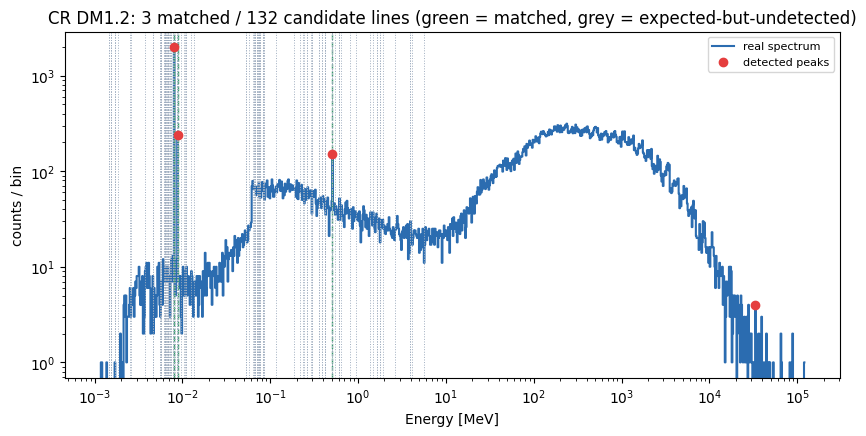

In [8]:
def plot_line_detection(name, E, result):
    edges = np.asarray(result["energy_bins"])
    centres = 0.5 * (edges[:-1] + edges[1:])
    counts, _ = np.histogram(E, bins=edges)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.step(centres, counts, where="mid", color="#2b6cb0", label="real spectrum")

    for m in result["matched_lines"]:
        ax.axvline(m["candidate_energy_mev"], color="#38a169", lw=1, ls="--")
    for c in result["unmatched_candidates"]:
        ax.axvline(c["candidate_energy_mev"], color="#a0aec0", lw=0.7, ls=":")

    peak_e = [p["energy_mev"] for p in result["detected_peaks"]]
    peak_c = [p["count"] for p in result["detected_peaks"]]
    ax.scatter(peak_e, peak_c, color="#e53e3e", zorder=5, label="detected peaks")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel("counts / bin")
    ax.set_title(
        f"{name}: {result['n_matched']} matched / {result['n_candidate_lines']} "
        "candidate lines (green = matched, grey = expected-but-undetected)"
    )
    ax.legend(fontsize=8)
    plt.show()


plot_line_detection(SOURCE, E_all, line_result)

## Line-position audit (v0.8.1)

Before training anything, check the one input the mixture head cannot recover from:
**is each pinned line actually where the real events are?** With 4 eV widths, a line
misplaced by more than ~1 FWHM produces a generated peak that does not overlap the
real one at all — and the old bin-width recovery window was far too wide to notice.

This measures each matched line directly from the raw events at eV resolution:
centroid, width, line and continuum counts, and the offset from the catalogue value
in units of the pinned FWHM. Same computation as `tools/line_centroid_audit.py`.

In [9]:
FWHM_MEV = X_IFU_RESOLUTION_EV * 1e-6
SIGMA_MEV = FWHM_MEV / 2.3548200450309493

E_sorted = np.sort(E_all)


def audit_line(E_c, label, search_fwhm=20.0, fail_fwhm=1.0):
    """Measure the real peak near E_c: centroid, width, line/continuum split."""
    half = search_fwhm * FWHM_MEV
    lo, hi = E_c - half, E_c + half
    i0, i1 = np.searchsorted(E_sorted, [lo, hi])
    sub = E_sorted[i0:i1]
    if sub.size < 10:
        return {"label": label, "verdict": "absent"}

    step = FWHM_MEV / 2.0
    nb = max(int(round((hi - lo) / step)), 8)
    hist, edges = np.histogram(sub, bins=nb, range=(lo, hi))
    med = float(np.median(hist))
    k = int(np.argmax(hist))
    if hist[k] < max(10.0, 5.0 * max(med, 1.0)):
        return {"label": label, "verdict": "absent"}

    thr = max(med * 2.0, 1.0)
    a = b = k
    while a > 0 and hist[a - 1] > thr:
        a -= 1
    while b < nb - 1 and hist[b + 1] > thr:
        b += 1
    core = sub[(sub >= edges[a]) & (sub < edges[b + 1])]
    n_cont = med * (b - a + 1)
    centroid = float(core.mean())
    std = float(core.std(ddof=1)) if core.size > 1 else 0.0
    delta = E_c - centroid
    return {
        "label": label, "verdict": "ok",
        "catalogue_keV": E_c * 1e3,
        "measured_keV": centroid * 1e3,
        "delta_eV": delta * 1e6,
        "delta_FWHM": abs(delta) / FWHM_MEV,
        "measured_FWHM_eV": std * 2.3548200450309493 * 1e6,
        "n_line": max(core.size - n_cont, 0.0),
        "pass": abs(delta) / FWHM_MEV <= fail_fwhm,
    }


audit = [audit_line(float(m["candidate_energy_mev"]), m["label"]) for m in matched]
audit_df = pd.DataFrame(audit)
print(f"{SOURCE}: line-position audit against the pinned {X_IFU_RESOLUTION_EV} eV FWHM\n")
print(audit_df.to_string(index=False))

bad = [a for a in audit if a["verdict"] != "ok" or not a["pass"]]
if bad:
    print(f"\n*** {len(bad)} line(s) are pinned more than 1 FWHM from their real peak - "
          f"the mixture head cannot reproduce them. Fix the candidate table before "
          f"training. ***")
else:
    print(f"\nAll {len(audit)} lines are within 1 FWHM of their measured position.")

CR DM1.2: line-position audit against the pinned 4.0 eV FWHM

            label verdict  catalogue_keV  measured_keV      delta_eV   delta_FWHM  measured_FWHM_eV  n_line  pass
e+e- annihilation      ok      510.99900    510.999000  1.110223e-10 2.775558e-11      2.625620e-10   117.0  True
      Cu K-alpha1      ok        8.00571      8.005710  0.000000e+00 0.000000e+00      0.000000e+00  1291.0  True
        Cu K-beta      ok        8.86534      8.865353 -1.253247e-02 3.133117e-03      3.662306e-01   154.0  True

All 3 lines are within 1 FWHM of their measured position.


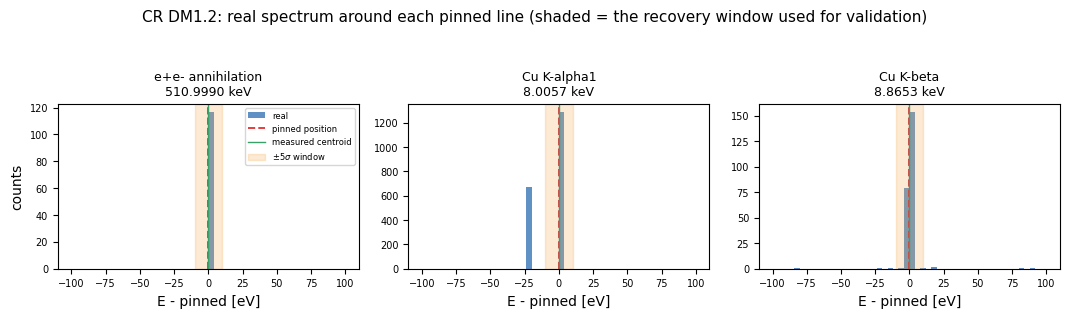

In [10]:
# Visual proof at line scale: the real spectrum in a +/-25 FWHM window around each
# line, with the pinned position marked. (With the Bearden table these markers sat
# 4-11 FWHM off the peak - visible here as a marker beside an empty bin.)

n_ax = len(matched)
fig, axes = plt.subplots(1, n_ax, figsize=(3.6 * n_ax, 3.2))
axes = np.atleast_1d(axes)
for ax, m, a in zip(axes, matched, audit):
    E_c = float(m["candidate_energy_mev"])
    half = 25 * FWHM_MEV
    sel = E_all[(E_all >= E_c - half) & (E_all <= E_c + half)]
    ax.hist((sel - E_c) * 1e6, bins=50, range=(-half * 1e6, half * 1e6),
            color="#2b6cb0", histtype="stepfilled", alpha=0.75, label="real")
    ax.axvline(0.0, color="#e53e3e", lw=1.4, ls="--", label="pinned position")
    if a["verdict"] == "ok":
        ax.axvline(-a["delta_eV"], color="#38a169", lw=1.0, label="measured centroid")
    ax.axvspan(-2.5 * X_IFU_RESOLUTION_EV, 2.5 * X_IFU_RESOLUTION_EV,
               color="#f6ad55", alpha=0.25, label=r"$\pm 5\sigma$ window")
    ax.set_title(f"{m['label']}\n{E_c*1e3:.4f} keV", fontsize=9)
    ax.set_xlabel("E - pinned [eV]")
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("counts")
axes[0].legend(fontsize=6)
fig.suptitle(f"{SOURCE}: real spectrum around each pinned line "
             f"(shaded = the recovery window used for validation)", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Standardization and Preprocessing

Same pipeline as v0.7.2 — `build_feature_dataframe` → `filter_particle_types_
continuous_geometry` → `split_feature_data` → `scale_continuous_features` →
`build_conditioning_and_weights` → `build_tf_datasets` — with three additions:

1. `energy_transform="log10"`: energy enters as the continuous column
   `energy_y = log10(E)` rather than a bin index.
2. **Gate targets** labelling each event continuum-or-line, now with a
   **resolution-driven bandwidth** (v0.8.1, defect D).
3. **CDF warp knots** for the continuum flow.

In [11]:
feature_pack = magi.build_feature_dataframe(
    prep,
    energy_binning_mode="log_fixed_count",
    n_bins=512,
    geometry_transform="quantile_u_r_u_v_phi_r_phi_v",
    n_quantiles=10000,
    random_state=42,
    # v0.8: continuous energy target y = log10(E) alongside the bin index
    energy_transform="log10",
)

magi.report_feature_dataframe(feature_pack)

energy_bins = feature_pack["energy_bins"]
n_energy_bins = feature_pack["n_energy_bins"]

quantile_transformers = feature_pack["quantile_transformers"]
qt_u_r = quantile_transformers["qt_u_r"]
qt_u_v = quantile_transformers["qt_u_v"]
qt_phi_r = quantile_transformers["qt_phi_r"]
qt_phi_v = quantile_transformers["qt_phi_v"]

geometry_metadata = feature_pack["geometry_metadata"]

print("Feature columns:", feature_pack["feat"].columns.tolist())
print("Geometry metadata:", geometry_metadata)


feat shape: (72544, 8)
geometry_transform: quantile_u_r_u_v_phi_r_phi_v

First rows:
  ParticleName  E_idx     u_r_q     u_v_q   phi_r_q   phi_v_q  energy_y  \
0          mu-    374 -1.102383  1.024673 -0.686061  0.676368  2.923797   
1          mu-    335  0.405026 -0.131835  0.240714 -0.922444  2.321080   
2          mu-    324 -0.144265 -0.087376  0.426704 -0.885176  2.151835   
3          mu-    330 -0.070472  0.570449 -0.523031  0.883917  2.238916   
4          mu-    323 -0.035229  0.095028 -0.707191  0.768072  2.132858   

   PrimBool  
0         1  
1         1  
2         1  
3         1  
4         1  

--- Finite check ---
Rows with NaN/Inf: 0

--- Feature ranges ---
     E_idx : 0  511
     u_r_q : -5.199337482452393  5.199337482452393
     u_v_q : -5.199337482452393  5.199337482452393
   phi_r_q : -5.199337482452393  5.199337482452393
   phi_v_q : -5.199337482452393  5.199337482452393
  energy_y : -2.9449543952941895  5.086092948913574
  PrimBool : 0  1

--- Quantile geom

In [12]:
# ==========================================================
# v0.8.1 line inputs + gate targets
#
# The gate-target bandwidth is now set by the PINNED LINE WIDTH, not by the
# detection bin width. The bin-width bandwidth was +/-125 eV at 1.49 keV,
# +/-320 eV at 8.9 keV and +/-43 keV at 511 keV - 31 to 10,000 detector FWHM -
# so every event in that neighbourhood was labelled a line event and the gate was
# supervised to over-route by roughly that ratio. That is the mechanism behind
# v0.8's 5.8x over-generated 511 line and the continuum holes beside the lines.
# ==========================================================

line_positions_mev = np.array([m["candidate_energy_mev"] for m in matched], dtype=np.float64)
line_positions_y = np.log10(line_positions_mev).astype(np.float32)

E_full = feature_pack["filtered_prep"]["features"]["Energy"].to_numpy()

gate_targets = magi.build_gate_targets(
    E_full,
    feature_pack["energy_bins"],
    matched,
    bandwidth_mode="resolution",          # v0.8.1
    bandwidth_fwhm_mev=FWHM_MEV,
)

# Legacy targets, for the diagnostic below only
gate_targets_bins = magi.build_gate_targets(E_full, feature_pack["energy_bins"], matched)

feat = feature_pack["feat"].copy()
for j in range(gate_targets.shape[1]):
    feat[f"gate_target_{j}"] = gate_targets[:, j]

cont_cols = ("u_r_q", "u_v_q", "phi_r_q", "phi_v_q", "energy_y") + tuple(
    f"gate_target_{j}" for j in range(gate_targets.shape[1])
)

# How much of the data each mode labels as a line, against the truth measured in
# the audit above. 1.0 = the gate is asked to route exactly the real line rate.
print(f"{SOURCE}: gate-target line mass vs the true line fraction\n")
print(f"  {'line':22s} {'true':>10s} {'bins mode':>12s} {'resolution':>12s}")
for j, (m, a) in enumerate(zip(matched, audit)):
    true_frac = (a["n_line"] / E_full.size) if a["verdict"] == "ok" else float("nan")
    f_bins = gate_targets_bins[:, j + 1].mean()
    f_res = gate_targets[:, j + 1].mean()
    print(f"  {m['label']:22s} {true_frac:10.5f} "
          f"{f_bins:9.5f} ({f_bins/true_frac:4.2f}x) "
          f"{f_res:9.5f} ({f_res/true_frac:4.2f}x)")
print(f"\ny_cont columns: {cont_cols}")
print(f"line_positions_y (log10 E): {line_positions_y}")

CR DM1.2: gate-target line mass vs the true line fraction

  line                         true    bins mode   resolution
  e+e- annihilation         0.00161   0.00955 (5.92x)   0.00158 (0.98x)
  Cu K-alpha1               0.01780   0.02241 (1.26x)   0.01755 (0.99x)
  Cu K-beta                 0.00212   0.00597 (2.81x)   0.00317 (1.50x)

y_cont columns: ('u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q', 'energy_y', 'gate_target_0', 'gate_target_1', 'gate_target_2', 'gate_target_3')
line_positions_y (log10 E): [-0.29157996 -2.0966     -2.0523045 ]


Dataset mode: continuous_geometry
Continuous geometry version: custom_continuous_geometry
Kept particle types: 6
Types: ['mu-', 'gamma', 'e-', 'anti_nu_e', 'nu_mu', 'e+']

Empirical probabilities:
         mu-  p=7.594839e-01
       gamma  p=1.509980e-01
          e-  p=7.104654e-02
   anti_nu_e  p=9.153066e-03
       nu_mu  p=8.973864e-03
          e+  p=3.446184e-04

Shapes:
X_cont_raw: (72544, 9)
E_idx     : (72544,)
y_type    : (72544,)

--- Continuous feature ranges ---
   u_r_q : -5.199337482452393  5.199337482452393
   u_v_q : -5.199337482452393  5.199337482452393
 phi_r_q : -5.199337482452393  5.199337482452393
 phi_v_q : -5.199337482452393  5.199337482452393
energy_y : -2.9449543952941895  5.086092948913574
gate_target_0 : 0.019607843831181526  1.0
gate_target_1 : 0.0  0.9803921580314636
gate_target_2 : 0.0  0.9803921580314636
gate_target_3 : 0.0  0.9803921580314636

--- Continuous means/std ---
   u_r_q : mean=-0.004488  std= 0.997568
   u_v_q : mean= 0.006138  std= 0.990955



Batch check:
X_cont batch shape: (4096, 9)
E_idx batch shape : (4096,)
cond batch shape  : (4096, 6)


Energy binning mode: log_fixed_count
Number of energy bins: 512

Energy train min/max:
0.00113513 121925.0

First bin: 0.0011351300000000005 0.0011768774477864126
Last bin : 117599.94680016847 121925.00000000009

Bin width summary:
min width : 4.174744778641208e-05
max width : 4325.053199831615
mean width: 238.13476340794944

--- Energy bin occupancy check ---
min counts: 0
max counts: 1364
mean counts: 99.1796875
empty bins: 38
empty bin fraction: 0.07421875

--- Log-fixed-count mode diagnostics ---
Requested bins: 512


log10(E) min/max: -2.9449543983390516 5.086092764263604
log-bin width min : 0.01568563898945813
log-bin width max : 0.015685638989459072
log-bin width mean: 0.015685638989458312


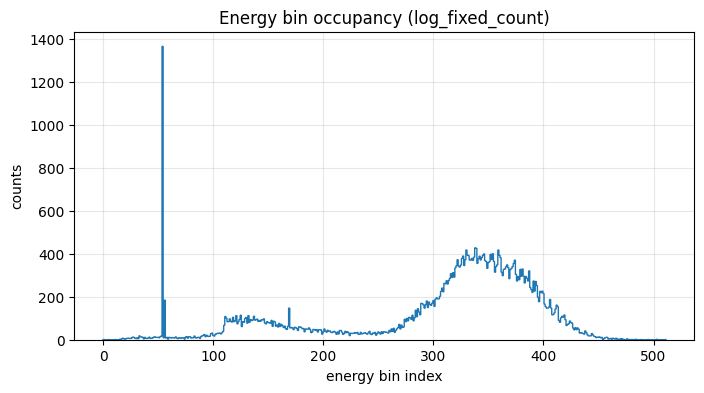

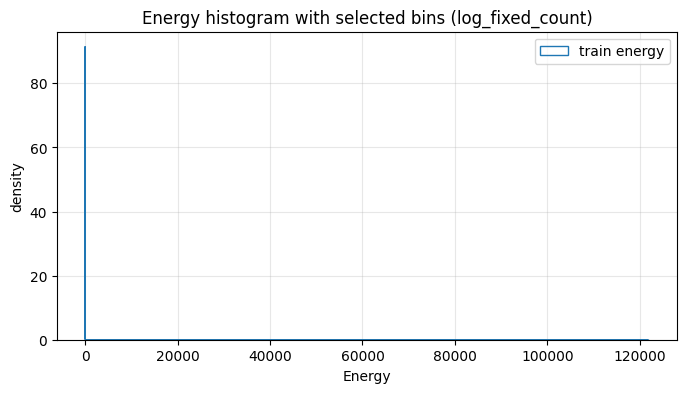

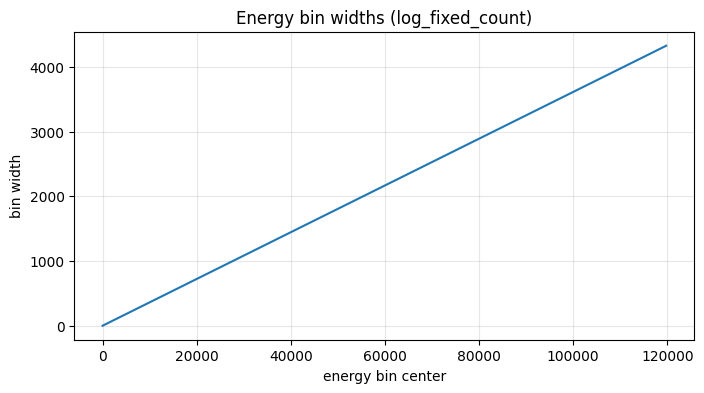

In [13]:
dataset_pack = magi.filter_particle_types_continuous_geometry(
    feat=feat,
    prob_threshold=1e-5,
    cont_cols=cont_cols,
)

magi.report_continuous_geometry_features(dataset_pack)

split_pack = magi.split_feature_data(
    dataset_pack,
    test_size_total=0.30,
    val_size_from_temp=0.50,
    random_state=42,
)

magi.report_split_summary(split_pack, n_types=dataset_pack["n_types"])

scaled_pack = magi.scale_continuous_features(
    split_pack,
    scale_cols=(),
)

magi.report_scaled_features(scaled_pack)

condition_pack = magi.build_conditioning_and_weights(
    scaled_pack,
    n_types=dataset_pack["n_types"],
    idx_to_type=dataset_pack["idx_to_type"],
    alpha=0.5,
)

magi.report_conditioning(condition_pack, n_types=dataset_pack["n_types"])

tf_pack = magi.build_tf_datasets(
    condition_pack,
    batch_size=4096,
    shuffle_buffer_cap=200_000,
)

magi.report_tf_datasets(tf_pack)

magi.report_energy_binning_diagnostics(
    energy_bins=feature_pack["energy_bins"],
    E_idx=dataset_pack["E_idx"],
    E_values=feature_pack["filtered_prep"]["features"]["Energy"].to_numpy(),
    idx_train=split_pack["idx_train"],
    energy_binning_mode=feature_pack["energy_config"]["mode"],
    bin_width=feature_pack["energy_config"]["bin_width"],
    n_bins=feature_pack["energy_config"]["n_bins"],
    min_counts=feature_pack["energy_config"]["min_counts"],
)

In [14]:
# ==========================================================
# Recover all main objects from package outputs - v0.8
# ==========================================================

feat = dataset_pack["feat"]

# model-side continuous block: [u_r_q, u_v_q, phi_r_q, phi_v_q, energy_y, gate_*]
X_cont_train_s = tf_pack["X_cont_train_s"]
X_cont_val_s = tf_pack["X_cont_val_s"]
X_cont_test_s = tf_pack["X_cont_test_s"]

X_cont_train = tf_pack["X_cont_train"]
X_cont_val = tf_pack["X_cont_val"]
X_cont_test = tf_pack["X_cont_test"]

# energy bin indices: kept for diagnostics/validation only - the v0.8 head does
# NOT consume them (it reads energy_y, column 4 of X_cont).
E_train = tf_pack["E_train"]
E_val = tf_pack["E_val"]
E_test = tf_pack["E_test"]

cond_train = tf_pack["cond_train"]
cond_val = tf_pack["cond_val"]
cond_test = tf_pack["cond_test"]

train_ds = tf_pack["train_ds"]
val_ds = tf_pack["val_ds"]
test_ds = tf_pack["test_ds"]

type_weights = tf_pack["type_weights"]

n_types = dataset_pack["n_types"]
idx_to_type = dataset_pack["idx_to_type"]
type_probs = dataset_pack["type_probs"]

cont_cols = dataset_pack["cont_cols"]
Y_CONT_DIM = X_cont_train_s.shape[1]
N_LINES = int(len(matched))

# raw physical references, per split
features_filtered = feature_pack["filtered_prep"]["features"]

E_all_filtered = features_filtered["Energy"].to_numpy()
u_r_all_raw = features_filtered["u_r"].to_numpy()
u_v_all_raw = features_filtered["u_v"].to_numpy()
phi_r_all_raw = features_filtered["phi_r"].to_numpy()
phi_v_all_raw = features_filtered["phi_v"].to_numpy()

idx_train = split_pack["idx_train"]
idx_val = split_pack["idx_val"]
idx_test = split_pack["idx_test"]

E_train_raw = E_all_filtered[idx_train]
E_val_raw = E_all_filtered[idx_val]
E_test_raw = E_all_filtered[idx_test]

print("Y_CONT_DIM:", Y_CONT_DIM, "(4 geometry + 1 energy_y + %d gate slots)" % (N_LINES + 1))
print("cont_cols :", cont_cols)
print("n_types   :", n_types, idx_to_type)
print("n_lines   :", N_LINES)
print("Available quantile transformers:", list(quantile_transformers.keys()))

Y_CONT_DIM: 9 (4 geometry + 1 energy_y + 4 gate slots)
cont_cols : ['u_r_q', 'u_v_q', 'phi_r_q', 'phi_v_q', 'energy_y', 'gate_target_0', 'gate_target_1', 'gate_target_2', 'gate_target_3']
n_types   : 6 {0: 'mu-', 1: 'gamma', 2: 'e-', 3: 'anti_nu_e', 4: 'nu_mu', 5: 'e+'}
n_lines   : 3
Available quantile transformers: ['qt_u_r', 'qt_u_v', 'qt_phi_r', 'qt_phi_v']


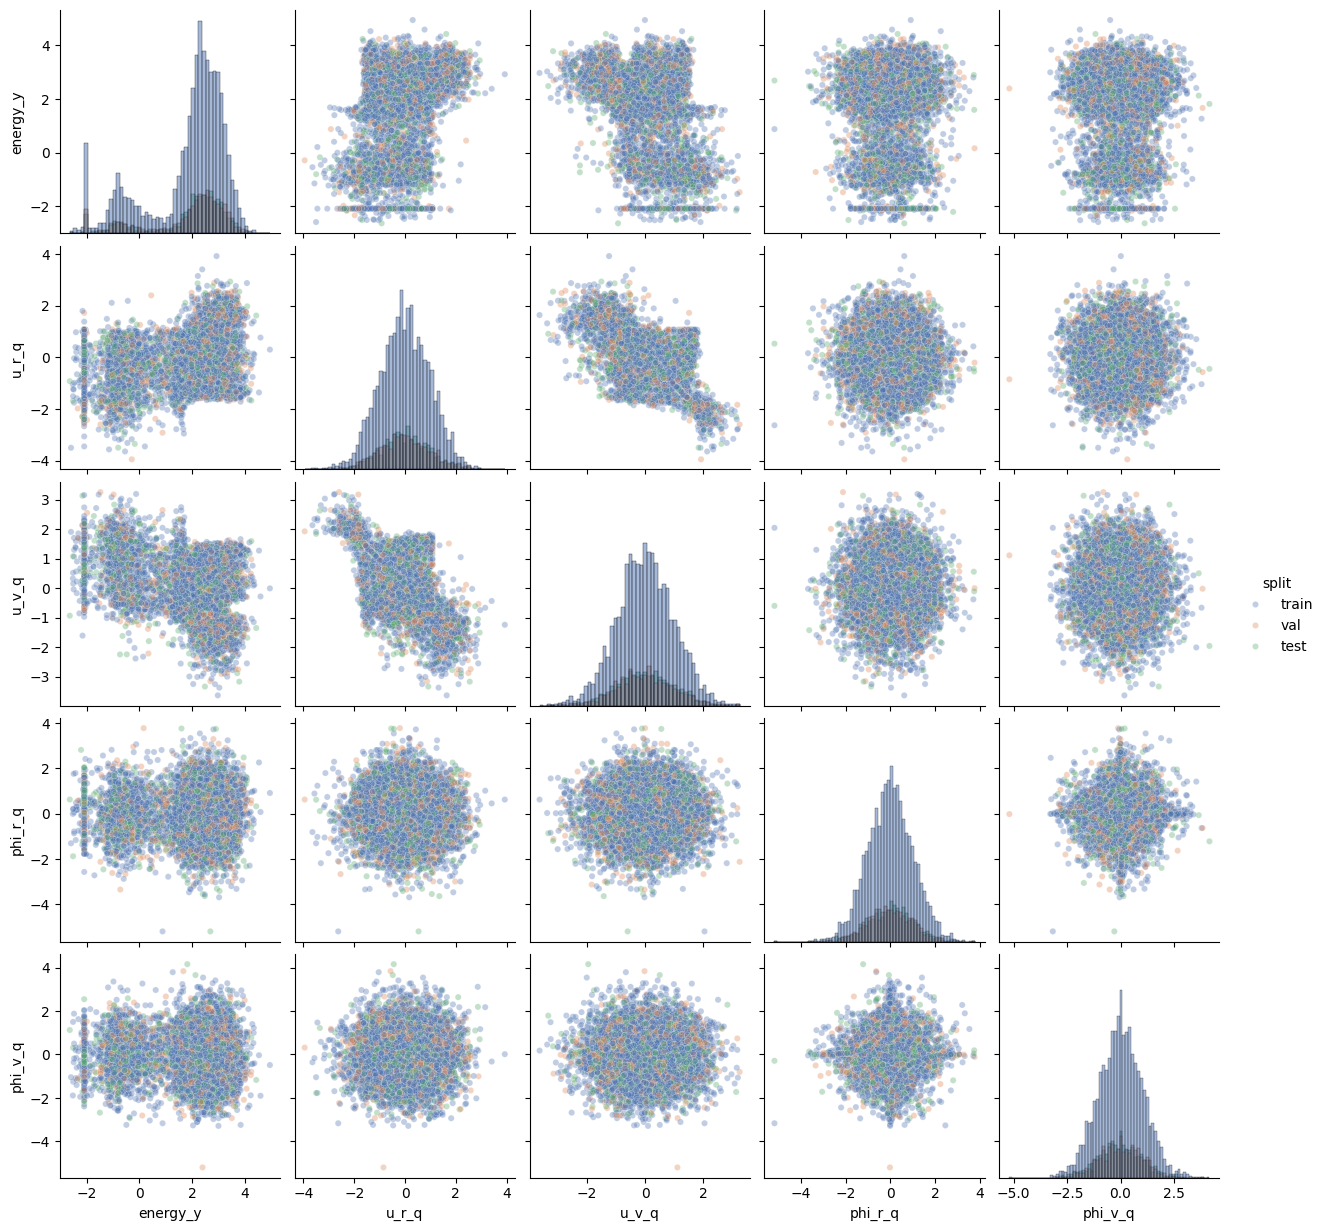

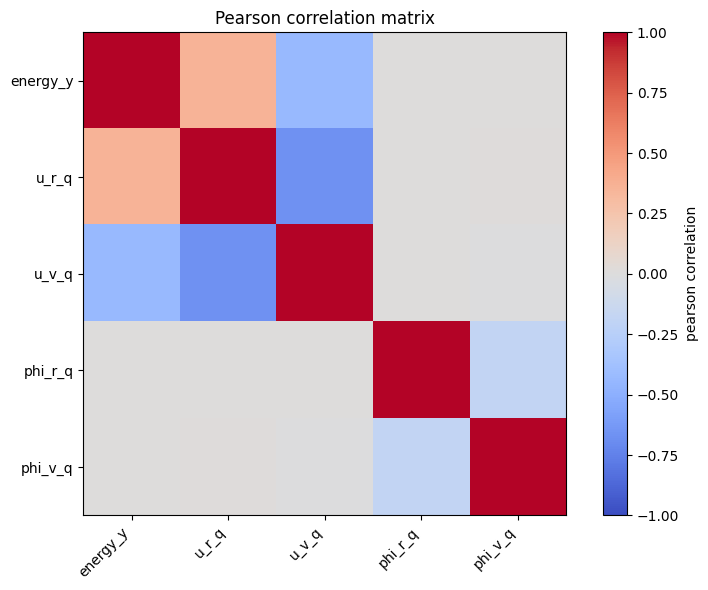

In [15]:
# ==========================================================
# Split sanity: the three splits must be statistically identical
# ==========================================================

df_train_plot = dataset_pack["feat"].iloc[split_pack["idx_train"]].copy()
df_val_plot   = dataset_pack["feat"].iloc[split_pack["idx_val"]].copy()
df_test_plot  = dataset_pack["feat"].iloc[split_pack["idx_test"]].copy()

df_train_plot["split"] = "train"
df_val_plot["split"]   = "val"
df_test_plot["split"]  = "test"

df_all_splits = pd.concat(
    [df_train_plot, df_val_plot, df_test_plot],
    axis=0,
    ignore_index=True,
)

model_space_cols = ["energy_y", "u_r_q", "u_v_q", "phi_r_q", "phi_v_q"]

magi.plot_pairwise_sample(
    df_all_splits,
    cols=model_space_cols,
    class_col="split",
    sample_size=8000,
)

magi.plot_correlation_matrix(
    df_all_splits,
    model_space_cols,
    method="pearson",
)

plt.show()

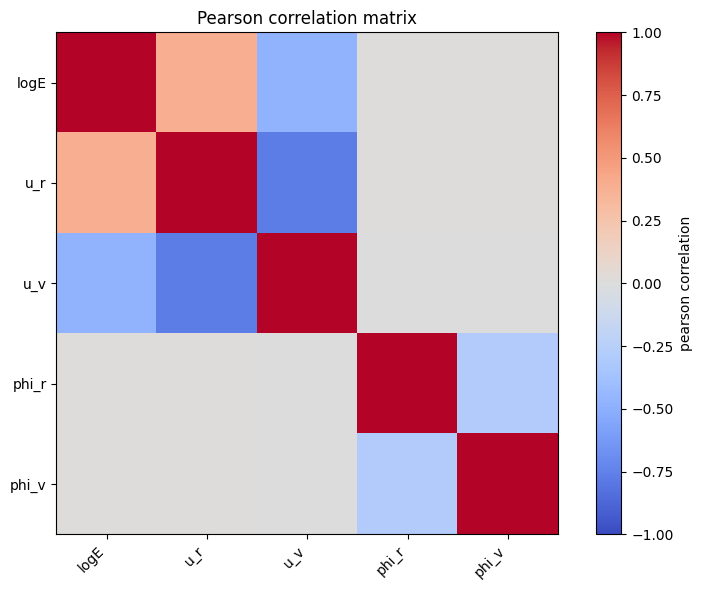

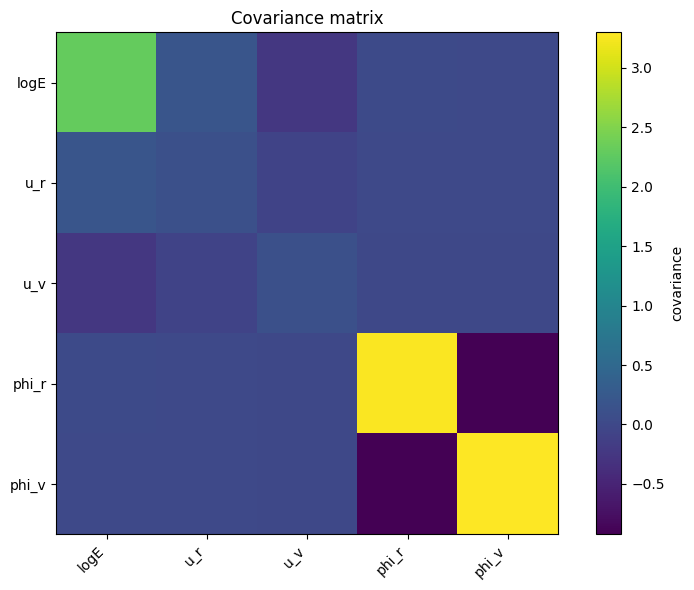

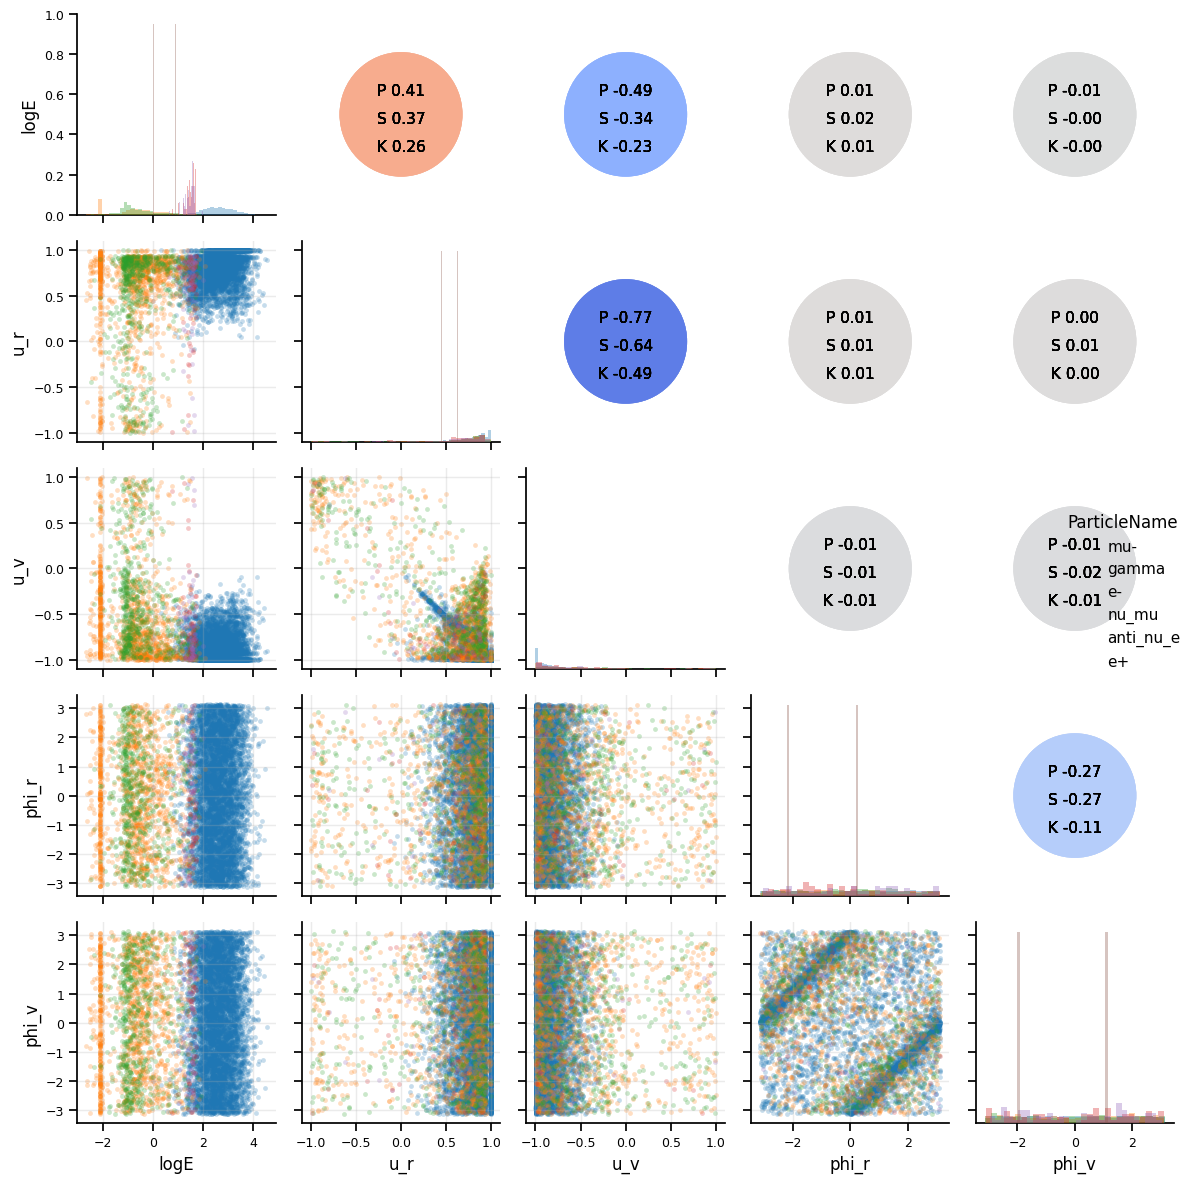

In [16]:
# ==========================================================
# Real-data structure the model has to reproduce: correlation, covariance and
# the full pairgrid over the physical variables. These are the reference for
# the identical plots on generated events in the validation section.
# ==========================================================

corr_df = feature_pack["filtered_prep"]["features"].copy()
corr_df["logE"] = np.log10(corr_df["Energy"].to_numpy())

corr_cols_phys = ["logE", "u_r", "u_v", "phi_r", "phi_v"]

corr_real = magi.plot_correlation_matrix(corr_df, corr_cols_phys, method="pearson")
cov_real = magi.plot_covariance_matrix(corr_df, corr_cols_phys)

magi.plot_pairgrid_physics(
    corr_df,
    cols=corr_cols_phys,
    class_col="ParticleName",
    sample_size=8000,
    lower_mode="scatter",
    bins=30,
    contour_levels=8,
    figsize_scale=2.4,
    theme="light",
    palette="tab10",
)

plt.show()

CDF warp: 256 knots over y in [-2.680, 4.792] -> z in [-3.72, 3.72]
affine reference (NOT used): y_mean=1.830 y_scale=1.516


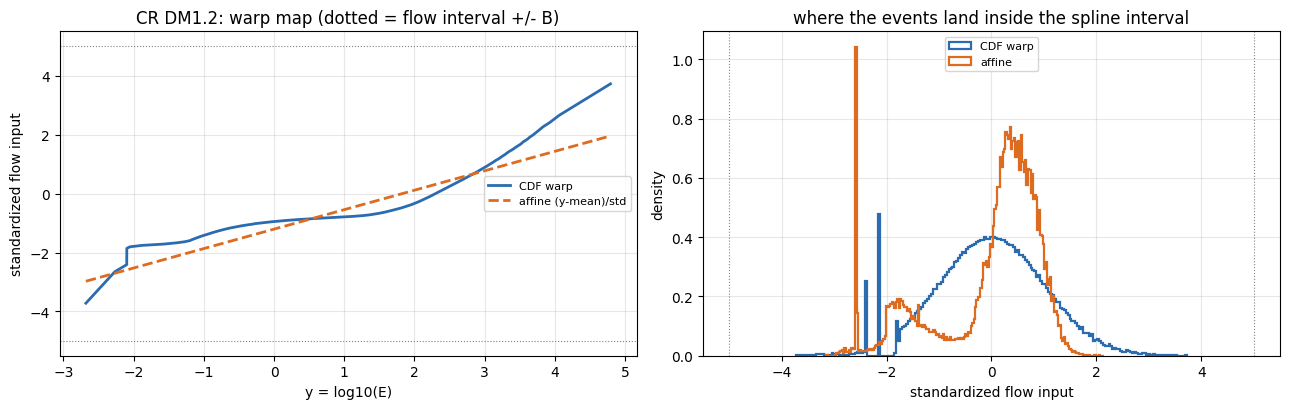

In [17]:
# ==========================================================
# CDF pre-warp knots for the flow continuum  (v0.8 Cycle 1)
#
# The RQS flow warps a FIXED interval [-B, B] (B = interval_half_width = 5) in
# standardized space, with frozen N(0,1) tails outside it. With plain affine
# standardization (y - mean)/std that interval is allocated by *variance*, not
# by where the events are:
#   - CR: the muon tail (to ~1e6 MeV) inflates the std, so the low-energy bulk
#     occupies a tiny slice of [-5, 5] and too few spline knots land on the
#     Compton edge -> it comes out over-smoothed.
#   - Small: the bulk is narrow, so the sparse low-energy tail lands near/beyond
#     B=5 -> the frozen normal tails take over and the tail density collapses.
#
# fit_cdf_warp_knots builds a monotone empirical-CDF -> N(0,1) map instead, so the
# knots are density-proportional: every quantile of the data gets comparable
# spline resolution and nothing falls outside the modelled interval. Validated on
# the --sparse-tail synthetic: deep-tail window ratio 0.00 (affine) -> 0.96 (cdf).
# See docs/v0.8_v072_comparison.md sec 6(b) and sec 9.
# ==========================================================

energy_y_all = feat["energy_y"].to_numpy()

warp_y_knots, warp_z_knots = magi.fit_cdf_warp_knots(
    energy_y_all,
    n_knots=256,
    eps=1e-4,
)

y_mean_affine = float(energy_y_all.mean())
y_scale_affine = float(energy_y_all.std())

print(f"CDF warp: {warp_y_knots.size} knots over "
      f"y in [{warp_y_knots[0]:.3f}, {warp_y_knots[-1]:.3f}] "
      f"-> z in [{warp_z_knots[0]:.2f}, {warp_z_knots[-1]:.2f}]")
print(f"affine reference (NOT used): y_mean={y_mean_affine:.3f} y_scale={y_scale_affine:.3f}")

# What the two standardizations do to the same data: the fraction of [-5, 5]
# that the physically interesting bulk actually occupies.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(warp_y_knots, warp_z_knots, color="#2b6cb0", lw=2, label="CDF warp")
axes[0].plot(warp_y_knots, (warp_y_knots - y_mean_affine) / y_scale_affine,
             color="#dd6b20", lw=2, ls="--", label="affine (y-mean)/std")
axes[0].axhline(5, color="0.5", lw=0.8, ls=":")
axes[0].axhline(-5, color="0.5", lw=0.8, ls=":")
axes[0].set_xlabel("y = log10(E)")
axes[0].set_ylabel("standardized flow input")
axes[0].set_title(f"{SOURCE}: warp map (dotted = flow interval +/- B)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

for lbl, z, c in [("CDF warp", np.interp(energy_y_all, warp_y_knots, warp_z_knots), "#2b6cb0"),
                  ("affine", (energy_y_all - y_mean_affine) / y_scale_affine, "#dd6b20")]:
    axes[1].hist(np.clip(z, -8, 8), bins=200, histtype="step", lw=1.6, color=c,
                 density=True, label=lbl)
axes[1].axvline(5, color="0.5", lw=0.8, ls=":")
axes[1].axvline(-5, color="0.5", lw=0.8, ls=":")
axes[1].set_xlabel("standardized flow input")
axes[1].set_ylabel("density")
axes[1].set_title("where the events land inside the spline interval")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Training with MAGI Package

### Model v0.8.1 `CVAE_MixEnergy_ContPhi_TaskAdaptive`

Architecture identical to v0.8 — flow continuum (24 bins, 3 transforms) with the CDF
pre-warp, fixed lines pinned to 4 eV FWHM, `energy_flow_condition="z_cond"` with the
learnable coupling prior `p(z|cond)`. Two configuration changes:

- **Gate targets** from the resolution bandwidth (cell above), so the gate is
  supervised toward the true line rate instead of 3.5–4.6× it.
- **`gate_focal_gamma = 1`**, down from 2. The focal term exists to stop the ~99%
  continuum majority from dominating the gate cross-entropy; with the labels no
  longer inflated, γ=2 over-corrects. On the narrow-line synthetic
  (`tools/synthetic_stress_test_cr_multimodal.py --line-sigma-y 0.002
  --gate-bandwidth-mode resolution`), γ=1 gave line recoveries 1.05–1.57 against
  γ=2's 1.08–2.57, between-line continuum 0.97/0.81/0.59 against 0.43/0.16/0.30, and
  continuum core 0.807 against 0.655.

`gate_class_weights` (per-line manual weights) remains available and
checkpoint-safe as the next lever, and is left `None` here. If it is needed, the
update must be **two-sided** (`clip(w·(target/recovery)^α, 1/cap, cap)`) — the
failure mode is over-generation, which a floor of 1.0 cannot correct.

In [18]:
# ==========================================================
# Configuration for later saving and reference - v0.8.1
# ==========================================================

EPOCHS = 40
LEARNING_RATE = 2e-4

line_logsigma_init = magi.line_logsigma_from_resolution(
    line_positions_mev, X_IFU_RESOLUTION_EV, fwhm=True,
)

model_config = {
    "model_class": "CVAE_MixEnergy_ContPhi_TaskAdaptive",
    "n_types": n_types,
    "line_positions_y": line_positions_y.tolist(),

    "latent_dim": 8,
    "hidden": [128, 128, 64],
    "beta": 0.2,

    "continuum_mode": "flow",
    "continuum_flow_bins": 24,
    "continuum_flow_transforms": 3,
    "continuum_flow_warp": "cdf",

    "energy_flow_condition": "z_cond",
    "prior": "coupling",

    "w_gate_aux": 2.0,
    "gate_focal_gamma": 1.0,          # v0.8.1: was 2.0
    "gate_class_weights": None,
    "line_logsigma_trainable": False,
    "x_ifu_resolution_ev": X_IFU_RESOLUTION_EV,
}

preprocessing_metadata = {
    "source": SOURCE,
    "geometry_transform": "quantile_u_r_u_v_phi_r_phi_v",
    "energy_transform": "log10",
    "cont_cols": list(cont_cols),
    "y_cont_dim": Y_CONT_DIM,

    "energy_bins": energy_bins,
    "type_probs": type_probs,
    "idx_to_type": idx_to_type,
    "n_types": n_types,

    "energy_binning_mode": feature_pack["energy_config"]["mode"],
    "energy_config": feature_pack["energy_config"],

    "candidate_lines_file": CANDIDATE_LINES_FILE,
    "gate_target_bandwidth_mode": "resolution",
    "matched_lines": [
        {"label": m["label"], "candidate_energy_mev": float(m["candidate_energy_mev"]),
         "count": int(m["count"])}
        for m in matched
    ],
    "line_position_audit": audit,
    "line_positions_y": line_positions_y.tolist(),
    "line_logsigma_init": np.asarray(line_logsigma_init).tolist(),

    "geometry_metadata": geometry_metadata,
    "quantile_transformer_keys": list(quantile_transformers.keys()),
}

print("pinned per-line logsigma (log10-E space):",
      np.round(np.asarray(line_logsigma_init), 4))

pinned per-line logsigma (log10-E space): [-13.4483  -9.2921  -9.3941]


In [19]:
magi.initialize_environment(seed=42, cpu_only=True, quiet=True)

model = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
    n_types=n_types,
    line_positions_y=line_positions_y,

    latent_dim=model_config["latent_dim"],
    hidden=tuple(model_config["hidden"]),
    beta=model_config["beta"],

    # --- flow continuum with CDF pre-warp (Cycle 1) ---
    continuum_mode="flow",
    continuum_flow_bins=model_config["continuum_flow_bins"],
    continuum_flow_transforms=model_config["continuum_flow_transforms"],
    continuum_flow_warp="cdf",
    continuum_flow_warp_y_knots=warp_y_knots,
    continuum_flow_warp_z_knots=warp_z_knots,

    # --- z-conditioning + learnable coupling prior ---
    energy_flow_condition="z_cond",
    prior="coupling",

    # --- lines + focal gate supervision (Cycle 2) ---
    w_gate_aux=model_config["w_gate_aux"],
    gate_focal_gamma=model_config["gate_focal_gamma"],   # v0.8.1: 1.0
    gate_class_weights=model_config["gate_class_weights"],
    line_logsigma_init=line_logsigma_init,
    line_logsigma_trainable=False,
)

magi.compile_model(model, learning_rate=LEARNING_RATE)

# v0.7.2 callback stack: early stopping + LR anneal on val_loss.
callbacks = magi.build_default_callbacks(
    monitor="val_loss",
    early_patience=8,
    lr_patience=6,
    factor=0.5,
    min_lr=1e-5,
    verbose=1,
)

# DUMMY BUILD FOR STRUCTURE INSPECTION
dummy_z = tf.zeros((1, model.latent_dim), dtype=tf.float32)
dummy_cond = tf.zeros((1, n_types), dtype=tf.float32)
_ = model.decode(dummy_z, dummy_cond)

magi.print_model_tree_with_params(model)
magi.print_duplicate_trainable_variables(model)


===== MAGI MODEL TREE (WITH PARAMS) =====
CVAE_MixEnergy_ContPhi_TaskAdaptive
  p(y|z,c): gated mixture of a continuum density and 3 fixed detector lines
  p(z|c)  : coupling
│
├── Encoder [trainable] (total=27856, trainable=27856, non_trainable=0)
│   ├── input: [y_cont, E_onehot, cond]
│   ├── z_mean
│   └── z_logvar
│
├── Decoder stem [trainable] (total=960, trainable=960, non_trainable=0)
│   └── light shared representation
│
├── Energy branch (short path) [trainable] (total=5472, trainable=5472, non_trainable=0)
│   ├── energy_gate_head [trainable] (total=196, trainable=196, non_trainable=0)
│   │   └── pi = softmax(.) over 1+3 = 4 slots
│   ├── energy_cont_head [trainable] (total=5216, trainable=5216, non_trainable=0)
│   ├── continuum_flow (RQS) [trainable] (total=15957, trainable=15957, non_trainable=0)
│   │   ├── 3 x 24-bin spline, domain [-5.0, 5.0], warp=cdf
│   │   └── cond: z_cond  ->  log p_cont(y) = log N(g(w);0,1) + log|dg/dw| + log|dw/dy|
│   └── 3 fixed line compone

In [20]:
magi.print_model_structure(model)


===== MAGI MODEL STRUCTURE =====
Model class   = CVAE_MixEnergy_ContPhi_TaskAdaptive
latent_dim    = 8
n_types       = 6
n_lines       = 3 (mixture energy head)
continuum     = flow (warp=cdf, K=1)
prior         = coupling
y_cont_dim    = 9

--- Generative model (what sampling actually does) ---
  cond c   : particle-type one-hot, dim 6
  1. z ~ p(z | c)      learned coupling-flow prior, z in R^8
  2. h = decoder(z, c) shared stem -> per-variable branches
  3. y ~ p(y | h)      factorized over the physical variables:
       energy_y = log10(E/MeV) ~ gate-weighted mixture (below)
       u_r_q    ~ N(mu(h), sigma(h))   (quantile-transformed)
       u_v_q    ~ N(mu(h), sigma(h))   (quantile-transformed)
       phi_r_q  ~ N(mu(h), sigma(h))   (quantile-transformed)
       phi_v_q  ~ N(mu(h), sigma(h))   (quantile-transformed)
  4. invert the quantile transforms -> physical (x,y,z, vx,vy,vz, E)

--- Latent prior p(z | c) ---
  mode : coupling (learned, conditional)
  6 affine coupling laye

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 128)       │      2,048 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_12      │ (None, 128)       │          0 │ dense_18[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 128)       │     16,512 │ leaky_re_lu_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_13      │ (None, 128)       │          0 │ dense_19[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      8,256 │ leaky_re_lu_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_14      │ (None, 64)        │          0 │ dense_20[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │        520 │ leaky_re_lu_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_logvar (Dense)    │ (None, 8)         │        520 │ leaky_re_lu_14[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,856 (108.81 KB)

 Trainable params: 27,856 (108.81 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_30 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_31 (LeakyReLU)      │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,576 (64.75 KB)

 Trainable params: 16,576 (64.75 KB)

 Non-trainable params: 0 (0.00 B)


--- ur_mu_head ---
<Dense name=ur_mu, built=True>

--- ur_logsigma_head ---
<Dense name=ur_logsigma, built=True>

--- uv_mu_head ---
<Dense name=uv_mu, built=True>

--- uv_logsigma_head ---
<Dense name=uv_logsigma, built=True>

--- phi_r_mu_head ---
<Dense name=phi_r_mu, built=True>

--- phi_r_logsigma_head ---
<Dense name=phi_r_logsigma, built=True>

--- phi_v_mu_head ---
<Dense name=phi_v_mu, built=True>

--- phi_v_logsigma_head ---
<Dense name=phi_v_logsigma, built=True>

--- energy_gate_head (mixture gate logits) ---
<Dense name=energy_gate_logits, built=True>

--- Task / loss weights ---
  energy : 1.0
      ur : 1.0
      uv : 1.0
   phi_r : 1.0
   phi_v : 1.0


In [21]:
# ~48 min for CR / ~33 min for Small at 40 epochs on the M1 CPU.
# verbose=2 keeps one line per epoch (readable in a long run).
t0 = time.time()

history = magi.fit_model(
    model=model,
    train_ds=train_ds,
    val_ds=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2,
)

n_epochs_run = len(history.history["loss"])
print(f"\n{SOURCE}: trained {n_epochs_run} epochs in {time.time() - t0:.0f}s")
print(f"  val energy_mixture_nll = {history.history['val_energy_mixture_nll'][-1]:.4f}")
print(f"  val gate_aux_loss      = {history.history['val_gate_aux_loss'][-1]:.4f}")
print(f"  val kl                 = {history.history['val_kl'][-1]:.4f}")
print(f"  pinned per-line logsigma = {np.round(model._line_logsigma_clipped().numpy(), 3)}")

Epoch 1/40


13/13 - 14s - 1s/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: 2.4773 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.9084 - kl: 0.1440 - loss: 6.3542 - nll: 6.3094 - phi_r_nll: 0.5265 - phi_v_nll: 0.5023 - rec: 6.3094 - sigma_reg: 0.0161 - ur_nll: 0.4983 - uv_nll: 0.4882 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: 2.3201 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.8017 - val_kl: 0.1496 - val_loss: 5.9842 - val_nll: 5.9383 - val_phi_r_nll: 0.5231 - val_phi_v_nll: 0.5082 - val_rec: 5.9383 - val_sigma_reg: 0.0161 - val_ur_nll: 0.4979 - val_uv_nll: 0.4857 - learning_rate: 2.0000e-04


Epoch 2/40


13/13 - 1s - 86ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: 2.2198 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.7040 - kl: 0.1996 - loss: 5.6856 - nll: 5.6297 - phi_r_nll: 0.5266 - phi_v_nll: 0.5034 - rec: 5.6297 - sigma_reg: 0.0160 - ur_nll: 0.4947 - uv_nll: 0.4770 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: 2.0540 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.5882 - val_kl: 0.2536 - val_loss: 5.2810 - val_nll: 5.2142 - val_phi_r_nll: 0.5204 - val_phi_v_nll: 0.5065 - val_rec: 5.2142 - val_sigma_reg: 0.0160 - val_ur_nll: 0.4904 - val_uv_nll: 0.4664 - learning_rate: 2.0000e-04


Epoch 3/40


...

13/13 - 1s - 70ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -1.0708e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.0390 - kl: 12.4139 - loss: -3.2612e+00 - nll: -5.7461e+00 - phi_r_nll: -1.2646e+00 - phi_v_nll: -1.6761e+00 - rec: -5.7461e+00 - sigma_reg: 0.0021 - ur_nll: -2.2329e-01 - uv_nll: -1.5894e+00 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -1.2809e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0386 - val_kl: 12.5338 - val_loss: -1.6317e+00 - val_nll: -4.1410e+00 - val_phi_r_nll: 0.7707 - val_phi_v_nll: -1.6087e+00 - val_rec: -4.1410e+00 - val_sigma_reg: 0.0026 - val_ur_nll: -2.0593e-01 - val_uv_nll: -1.8934e+00 - learning_rate: 2.0000e-04


Epoch 40/40


13/13 - 1s - 65ms/step - continuum_balance: 0.0000e+00 - continuum_repulsion: 0.0000e+00 - energy_mixture_nll: -1.1632e+00 - flow_line_repulsion: 0.0000e+00 - gate_aux_loss: 0.0375 - kl: 12.3052 - loss: -3.4052e+00 - nll: -5.8687e+00 - phi_r_nll: -1.1747e+00 - phi_v_nll: -1.7290e+00 - rec: -5.8687e+00 - sigma_reg: 0.0024 - ur_nll: -2.0580e-01 - uv_nll: -1.6709e+00 - val_continuum_balance: 0.0000e+00 - val_continuum_repulsion: 0.0000e+00 - val_energy_mixture_nll: -1.1708e+00 - val_flow_line_repulsion: 0.0000e+00 - val_gate_aux_loss: 0.0375 - val_kl: 12.1692 - val_loss: -3.3450e+00 - val_nll: -5.7815e+00 - val_phi_r_nll: -1.2429e+00 - val_phi_v_nll: -1.6407e+00 - val_rec: -5.7815e+00 - val_sigma_reg: 0.0026 - val_ur_nll: -1.9148e-01 - val_uv_nll: -1.6106e+00 - learning_rate: 2.0000e-04


Restoring model weights from the end of the best epoch: 38.



CR DM1.2: trained 40 epochs in 52s
  val energy_mixture_nll = -1.1708
  val gate_aux_loss      = 0.0375
  val kl                 = 12.1692
  pinned per-line logsigma = [-13.448  -9.292  -9.394]



Available history keys:
['continuum_balance', 'continuum_repulsion', 'energy_mixture_nll', 'flow_line_repulsion', 'gate_aux_loss', 'kl', 'loss', 'nll', 'phi_r_nll', 'phi_v_nll', 'rec', 'sigma_reg', 'ur_nll', 'uv_nll', 'val_continuum_balance', 'val_continuum_repulsion', 'val_energy_mixture_nll', 'val_flow_line_repulsion', 'val_gate_aux_loss', 'val_kl', 'val_loss', 'val_nll', 'val_phi_r_nll', 'val_phi_v_nll', 'val_rec', 'val_sigma_reg', 'val_ur_nll', 'val_uv_nll', 'learning_rate']


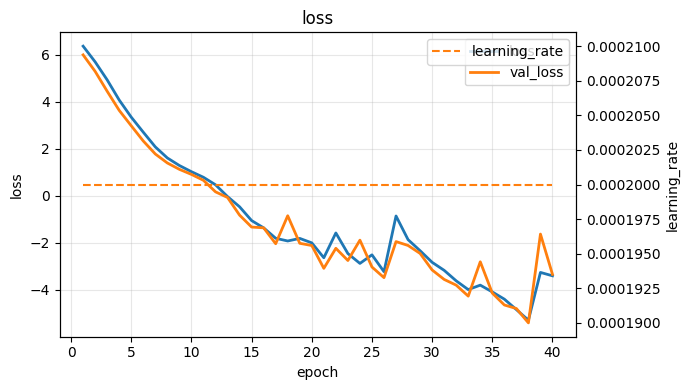

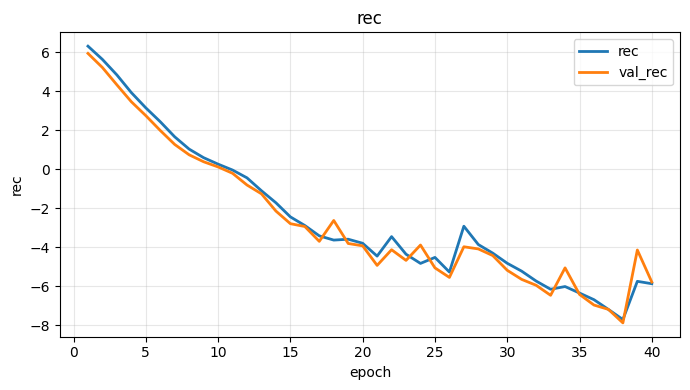

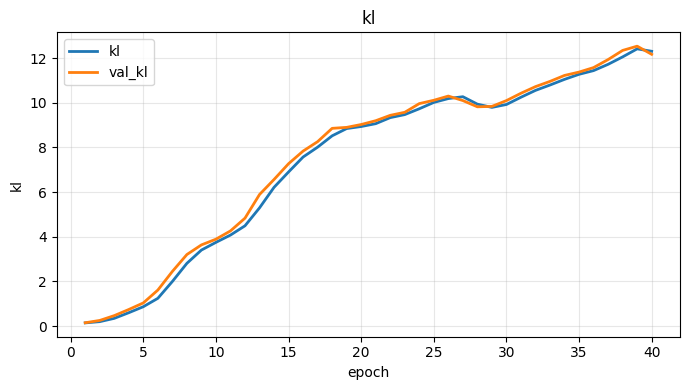

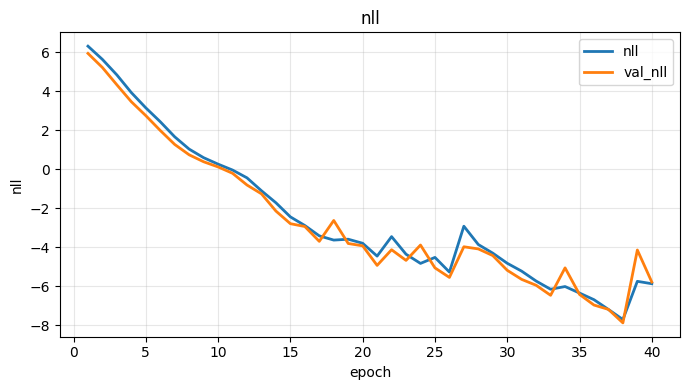

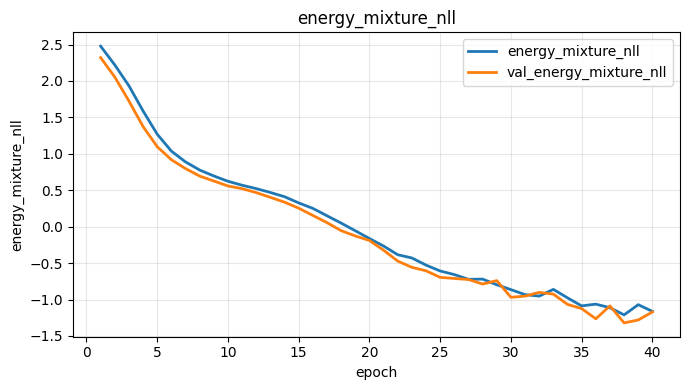

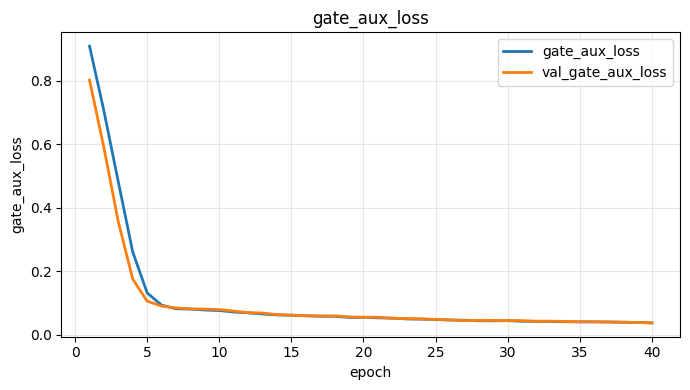

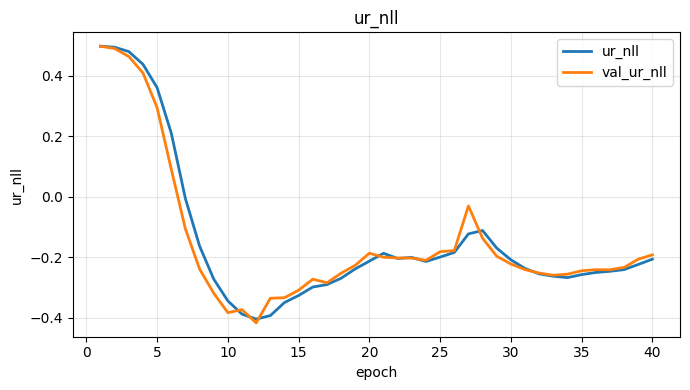

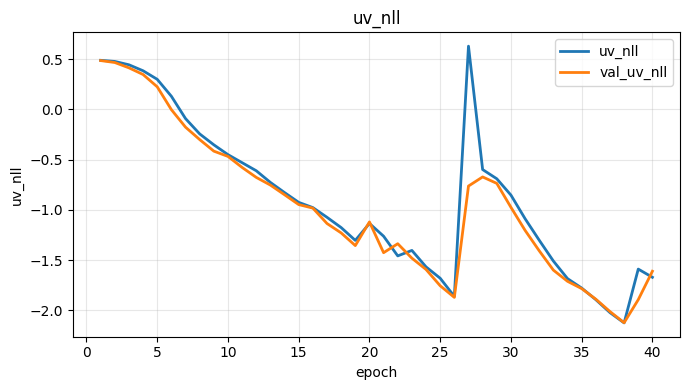

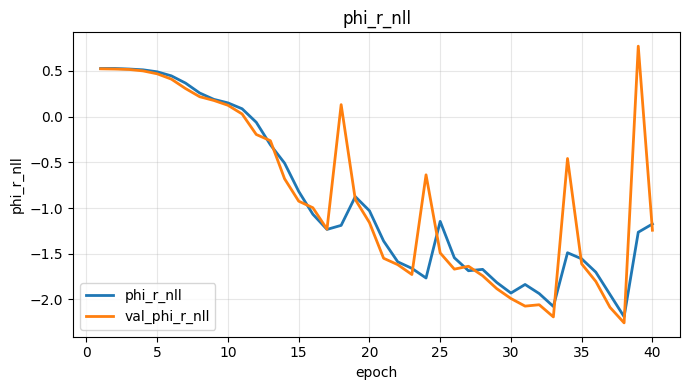

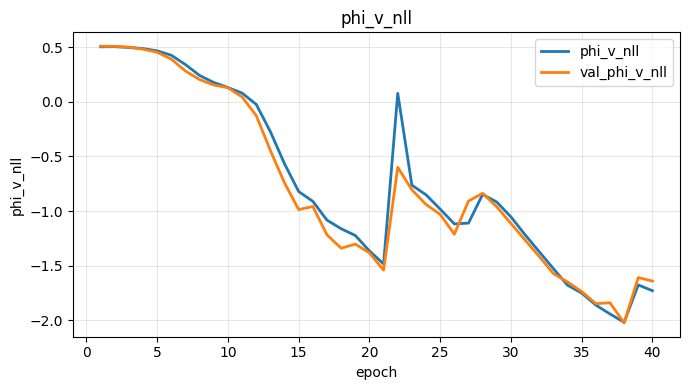

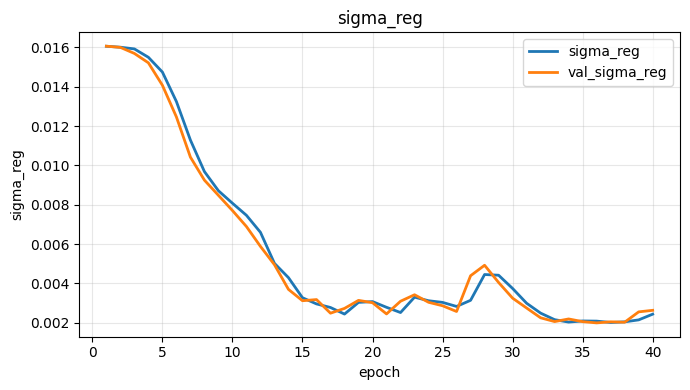

In [22]:
# v0.8 metric set: energy_mixture_nll replaces v0.7.2's energy_ce, and
# gate_aux_loss is the line-routing supervision to watch.
magi.plot_history(
    history,
    keys=[
        "loss",
        "rec",
        "kl",
        "nll",
        "energy_mixture_nll",
        "gate_aux_loss",
        "ur_nll",
        "uv_nll",
        "phi_r_nll",
        "phi_v_nll",
        "sigma_reg",
    ],
)

## Generation and Validation

Validation runs on the **corrected** metric (v0.8.1 defects A and B):

- generation is matched to the real event count, and the recovery ratio is
  normalized by `N_real/N_gen` regardless;
- the line window is **±5σ of the pinned 4 eV FWHM**, not two detection bins, and
  the local continuum is subtracted from both counts using side-bands just outside
  it, so the ratio compares *line* events;
- lines whose subtracted count is not significant are reported as such rather than
  given a spurious ratio, and overlapping windows are flagged;
- `component_recovery` (the gate's routing fraction over the real line fraction) is
  a window-free cross-check: it should agree with the windowed ratio.

Then the usual three levels: energy marginal, per-variable marginals, and joint
structure (pairgrid + covariance/correlation triptychs — the test the coupling prior
exists for).

In [ ]:
### SKIP MODEL TRAINING AND DIRECTLY LOAD A TRAINED MODEL FOR GENERATION AND EVALUATION
#
# The v0.8 checkpoint is self-describing: model.to_generation_config() stores the
# line positions, continuum_mode, flow + warp knots, prior type, focal gamma and
# per-line widths, so the loader rebuilds exactly this architecture. Just read the
# saved JSON back - no need to retype the config as in v0.7.2.

save_dir = f"trained_models/v0_8_1_{SOURCE}"
model_name = f"mix_{SOURCE}"

with open(os.path.join(save_dir, f"{model_name}_config.json")) as f:
    saved_config = json.load(f)

model = magi.load_task_adaptive_model_for_generation(
    save_dir=save_dir,
    model_name=model_name,
    model_config=saved_config,
    energy_bins=energy_bins,
    u_v_bins=None,              # v0.8: not used
    n_types=n_types,
    type_weights=type_weights,
    radius=R,
    compile_model_fn=magi.compile_model,
    verbose=1,
)

In [23]:
# ==========================================================
# Generate and reconstruct physics
# Generation is chunked so a large NGEN stays memory-safe.
# ==========================================================

NGEN = int(len(X_cont_test))
# NGEN = int(1e6)
CHUNK = 500_000

def generate_physics(model, n_gen, chunk=CHUNK):
    parts = []
    done = 0
    while done < n_gen:
        m = min(chunk, n_gen - done)
        gen_raw = magi.generate_latent_outputs(
            model=model,
            n_samples=m,
            type_probs=type_probs,
            n_types=n_types,
            idx_to_type=idx_to_type,
        )
        gen_feat = magi.reconstruct_generated_features(
            gen_raw,
            # v0.8: energy comes from the mixture head as y = log10(E),
            # NOT from an energy bin index.
            energy_head_mode="mixture",
            energy_transform="log10",
            geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
            qt_u_r=qt_u_r,
            qt_u_v=qt_u_v,
            qt_phi_r=qt_phi_r,
            qt_phi_v=qt_phi_v,
        )
        parts.append(magi.reconstruct_generated_physics(gen_feat, center=center, radius=R))
        done += m
        print(f"  generated {done:,}/{n_gen:,}", flush=True)

    if len(parts) == 1:
        return parts[0]
    out = {}
    for k, v in parts[0].items():
        if isinstance(v, np.ndarray) and v.ndim >= 1 and v.shape[0] == parts[0]["E_gen"].shape[0]:
            out[k] = np.concatenate([p[k] for p in parts], axis=0)
        else:
            out[k] = v
    return out


gen_phys = generate_physics(model, NGEN)

real_phys = magi.reconstruct_real_test_physics(
    # only the 4 geometry columns - energy_y and the gate slots are model-side
    X_cont_test=X_cont_test[:, :4],
    E_test_raw=E_test_raw,
    qt_u_r=qt_u_r,
    qt_u_v=qt_u_v,
    qt_phi_r=qt_phi_r,
    qt_phi_v=qt_phi_v,
    center=center,
    radius=R,
    geometry_mode="quantile_u_r_u_v_phi_r_phi_v",
)

real_phys["phi_r_real"] = np.arctan2(real_phys["sphi_r_real"], real_phys["cphi_r_real"])
real_phys["phi_v_real"] = np.arctan2(real_phys["sphi_v_real"], real_phys["cphi_v_real"])
gen_phys["phi_r_gen"] = np.arctan2(gen_phys["sphi_r_gen"], gen_phys["cphi_r_gen"])
gen_phys["phi_v_gen"] = np.arctan2(gen_phys["sphi_v_gen"], gen_phys["cphi_v_gen"])

magi.report_generated_constraints(gen_phys, radius=R)

scores = magi.compute_wasserstein_scores(real_phys, gen_phys)
print("\nWasserstein distances (real vs generated):")
for k, v in scores.items():
    print(f"  {k:8s} {v:.5f}")

  generated 10,882/10,882


--- CONSTRAINT CHECKS ---

Sphere constraint:
r_gen: mean 104.99999999996349 std 2.7894655893584545e-11 min 104.99999999989498 max 105.00000000000001
mean |r-R| = 3.648689576086672e-11

Direction norm:
||v||: mean 0.9999999999989999 std 9.907525786939826e-17 min 0.9999999999989998 max 0.9999999999990001
mean ||v||-1| = 1.0000319917050083e-12

Unit circle checks:
phi_r norm: mean 0.9999999999989999 std 8.647560896567687e-17 min 0.9999999999989998 max 0.9999999999990001
phi_v norm: mean 0.9999999999989999 std 8.748484535922645e-17 min 0.9999999999989998 max 0.9999999999990001

Physical variables:
E_gen: min 0.0016703167 max 70028.13
u_r_gen min/max: -0.9987244893606808 0.9999903372197118
u_v_gen min/max: -0.9999956112559258 0.9906423632989498
fraction u_v_gen > 0: 0.05247197206395883

Quantile variables:
u_r_q_gen: min=-4.883664608001709 max=4.8180084228515625 mean=-0.02380998246371746 std=1.1085237264633179
u_v_q_gen: min=-3.8933794498443604 max=3.183830499649048 mean=0.0203023403882980

In [24]:
# ==========================================================
# Line-integral recovery, v0.8.1 metric
# ==========================================================

E_real_full = feature_pack["filtered_prep"]["features"]["Energy"].to_numpy()
E_gen = gen_phys["E_gen"]

recovery = magi.compute_line_integral_recovery(
    E_real_full,
    E_gen,
    matched,
    feature_pack["energy_bins"],
    energy_component_idx_gen=gen_phys["energy_component_idx_gen"],
    resolution_ev=X_IFU_RESOLUTION_EV,     # +/-5 sigma window instead of 2 bins
)

scale = recovery[0]["gen_scale"]
print(f"{SOURCE}: line-integral recovery "
      f"(+/-{recovery[0]['window_half_width_mev']*1e6:.1f} eV window, "
      f"continuum-subtracted, N_real/N_gen = {scale:.3f})\n")
print(f"  {'line':22s} {'real_line':>10s} {'gen_line':>10s} {'recovery':>9s} "
      f"{'routing':>8s}  verdict")
for r in recovery:
    rec = "  n/a" if r["recovery_ratio"] is None else f"{r['recovery_ratio']:9.3f}"
    cr = r.get("component_recovery")
    crs = "     n/a" if cr is None else f"{cr:8.3f}"
    v = ("LOW-SIG" if r.get("low_significance") else
         "PASS" if (r["recovery_ratio"] is not None
                    and 0.8 <= r["recovery_ratio"] <= 1.2) else "FAIL")
    note = f"  OVERLAPS {r['overlaps_lines']}" if r["overlaps_lines"] else ""
    print(f"  {r['label']:22s} {r['n_real_line']:10.1f} {r['n_gen_line']:10.1f} "
          f"{rec} {crs}  {v}{note}")

# Near-line continuum: did the gate dig a hole beside each line to feed it?
print(f"\n  near-line continuum (side-bands at 2-3x the window):")
for r in recovery:
    c, w = r["candidate_energy_mev"], r["window_half_width_mev"]
    nr = (np.sum((E_real_full >= c - 3*w) & (E_real_full <= c - 2*w))
          + np.sum((E_real_full >= c + 2*w) & (E_real_full <= c + 3*w)))
    ng = (np.sum((E_gen >= c - 3*w) & (E_gen <= c - 2*w))
          + np.sum((E_gen >= c + 2*w) & (E_gen <= c + 3*w)))
    ratio = (ng * scale / nr) if nr else float("nan")
    v = "PASS" if 0.85 <= ratio <= 1.15 else "FAIL"
    print(f"  {r['label']:22s} real={int(nr):8d} gen={int(ng):8d} ratio={ratio:6.3f}  {v}")

pd.DataFrame(recovery)[
    ["label", "n_real_line", "n_gen_line", "recovery_ratio",
     "component_recovery", "line_significance", "window_half_width_mev"]
]

CR DM1.2: line-integral recovery (+/-8.5 eV window, continuum-subtracted, N_real/N_gen = 6.666)

  line                    real_line   gen_line  recovery  routing  verdict
  e+e- annihilation           117.0       27.0     1.538    1.538  FAIL
  Cu K-alpha1                 616.0      297.0     3.214    2.078  FAIL
  Cu K-beta                   231.0       64.0     1.847    1.847  FAIL

  near-line continuum (side-bands at 2-3x the window):
  e+e- annihilation      real=       0 gen=       0 ratio=   nan  FAIL
  Cu K-alpha1            real=     675 gen=      67 ratio= 0.662  FAIL
  Cu K-beta              real=       3 gen=       1 ratio= 2.222  FAIL


,label,n_real_line,n_gen_line,recovery_ratio,component_recovery,line_significance,window_half_width_mev
0,e+e- annihilation,117.0,27.0,1.538405,1.538405,10.816654,0.000008
1,Cu K-alpha1,616.0,297.0,3.214168,2.077846,13.892774,0.000008
2,Cu K-beta,231.0,64.0,1.846974,1.846974,15.005062,0.000008


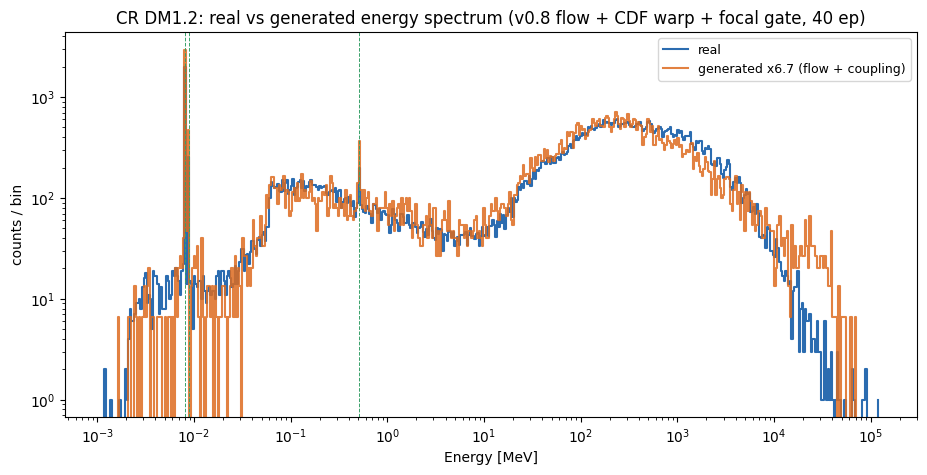

In [25]:
# ==========================================================
# Energy spectrum, real vs generated, on the detection binning.
# Log-log: this is the plot where the continuum shape (Compton edge, muon
# structure, low-energy tail) and the line spikes are both visible.
# ==========================================================

bins = np.asarray(feature_pack["energy_bins"])
real_counts, _ = np.histogram(E_real_full, bins=bins)
gen_counts, _ = np.histogram(E_gen, bins=bins)
scale = E_real_full.size / max(E_gen.size, 1)
centres = 0.5 * (bins[:-1] + bins[1:])

fig, ax = plt.subplots(figsize=(11, 5))
ax.step(centres, real_counts, where="mid", color="#2b6cb0", label="real")
ax.step(centres, gen_counts * scale, where="mid", color="#dd6b20", alpha=0.85,
        label=f"generated x{scale:.1f} (flow + coupling)")
for m in matched:
    ax.axvline(m["candidate_energy_mev"], color="#38a169", lw=0.7, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("counts / bin")
ax.set_title(f"{SOURCE}: real vs generated energy spectrum "
             f"(v0.8 flow + CDF warp + focal gate, {globals().get('n_epochs_run', EPOCHS)} ep)")
ax.legend(fontsize=9)
fig.savefig(f"./Plots/v0_8_real_{SOURCE}_spectrum.png", dpi=140, bbox_inches="tight")
plt.show()

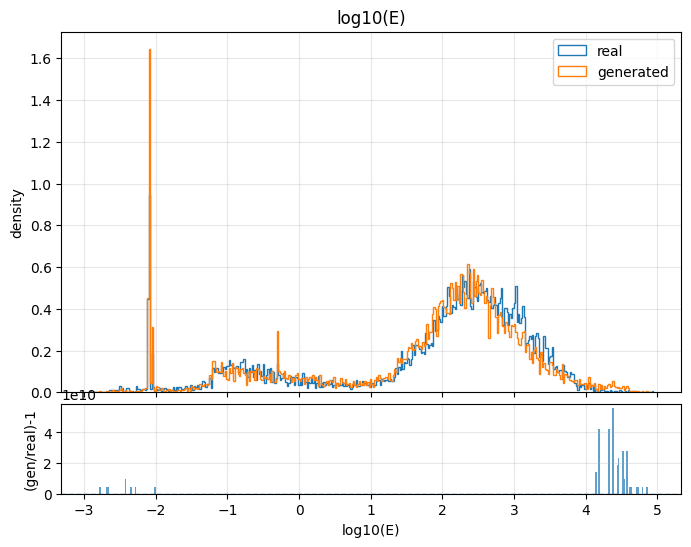

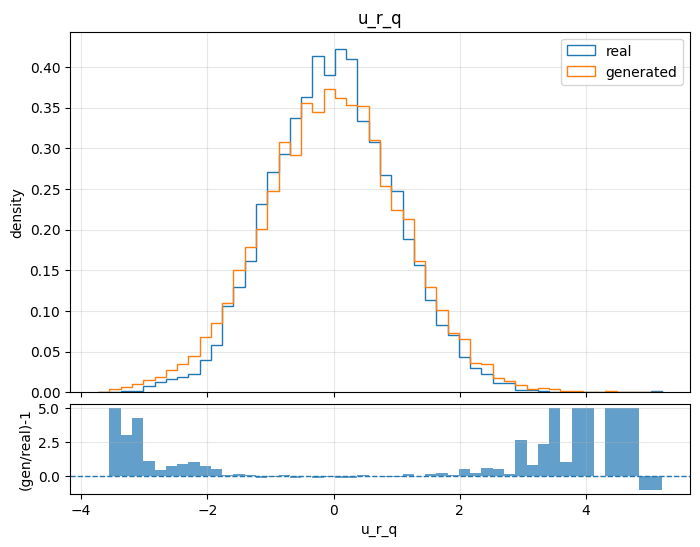

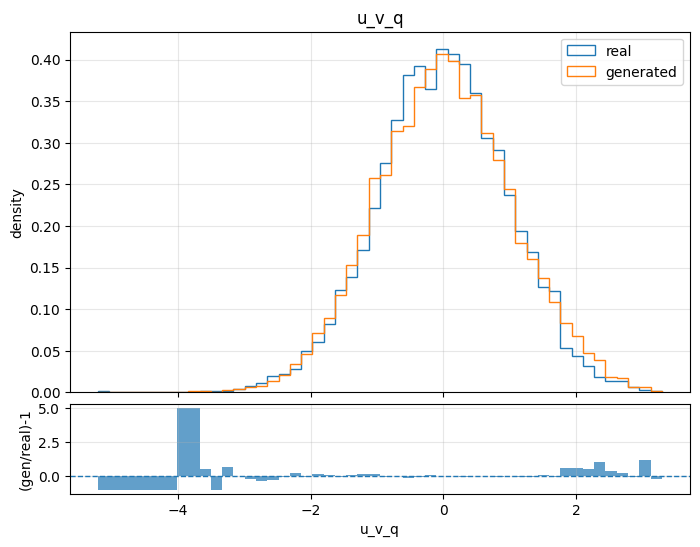

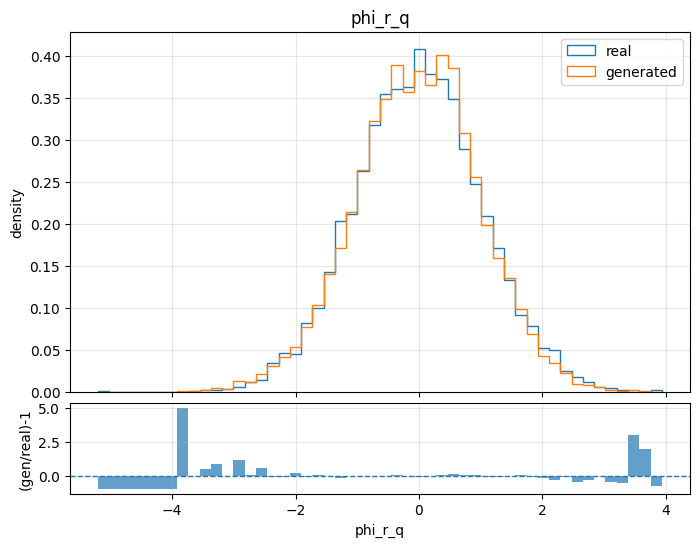

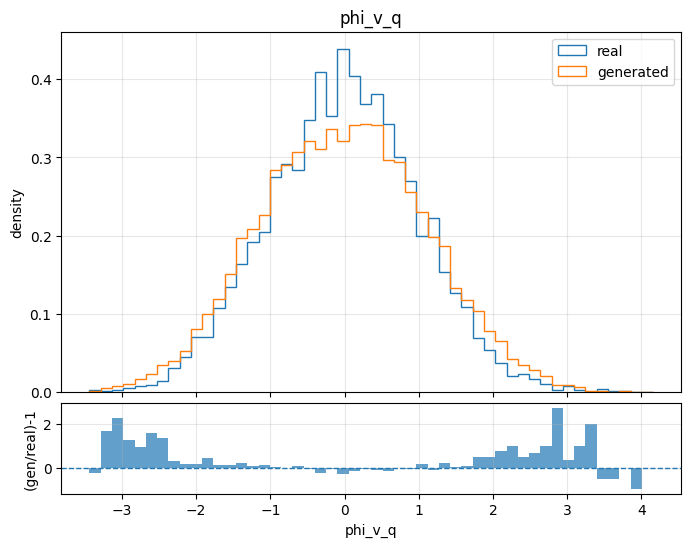

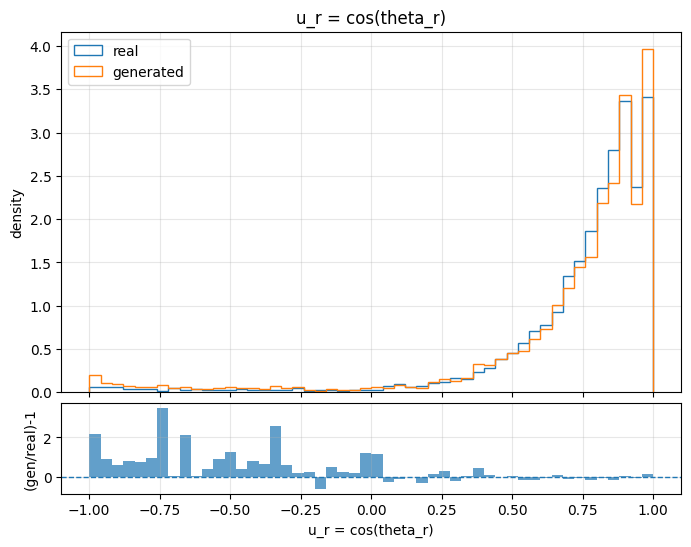

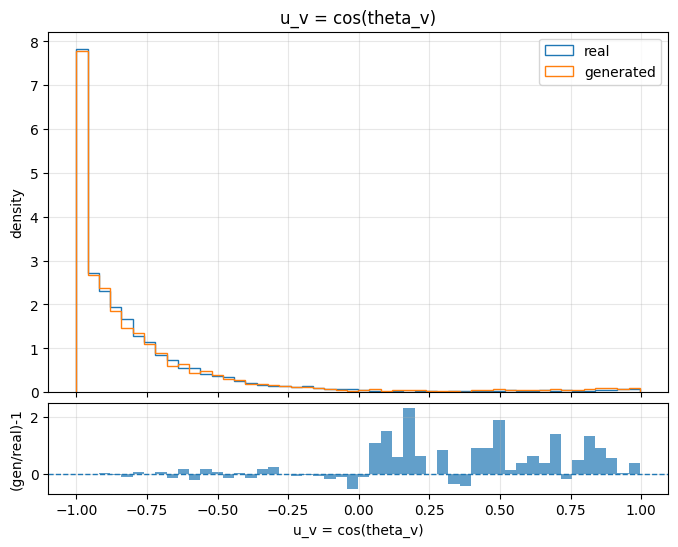

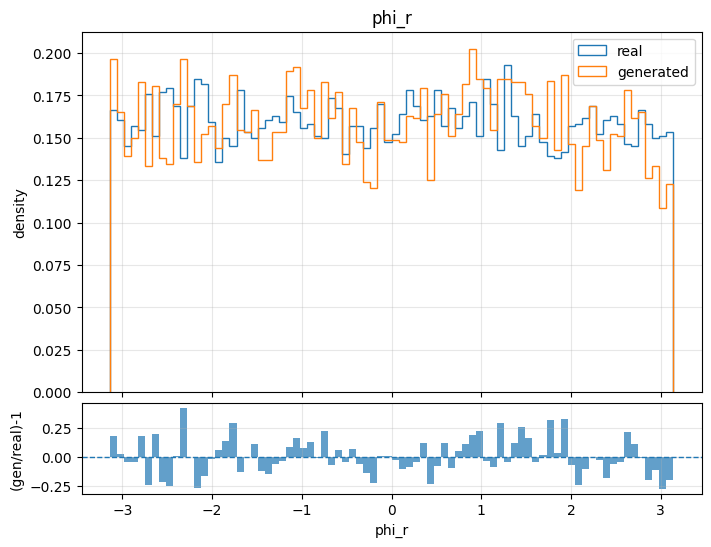

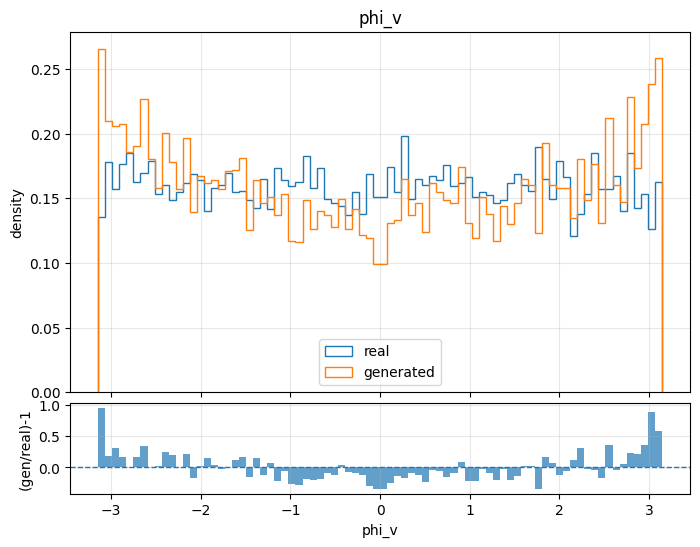

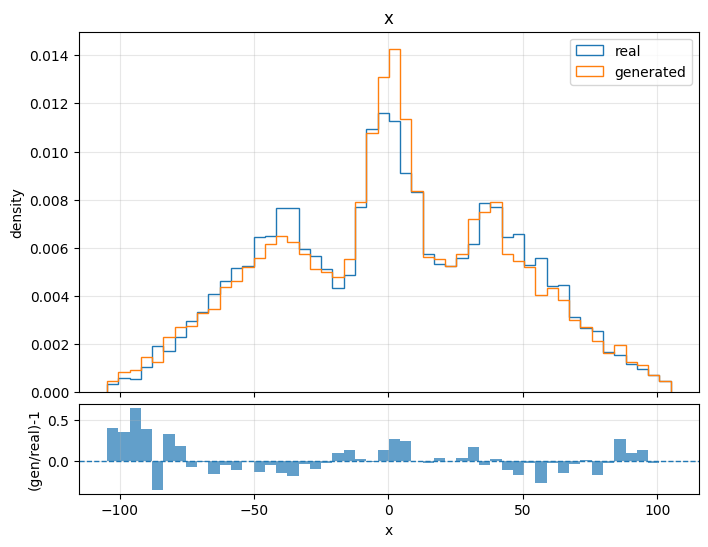

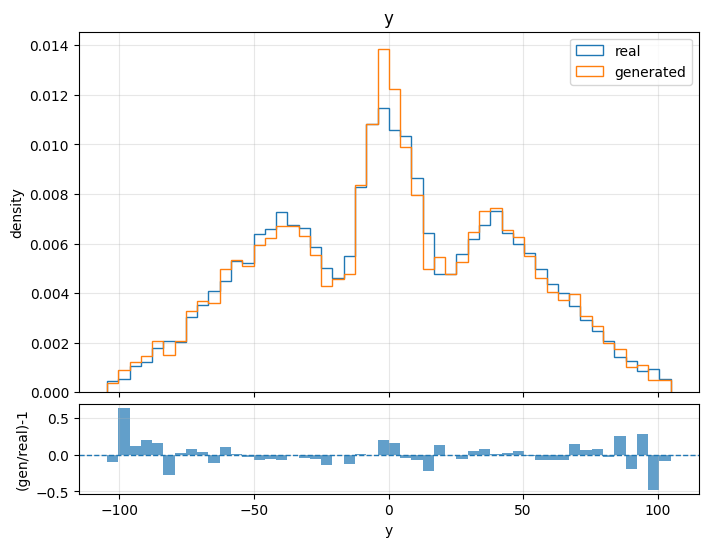

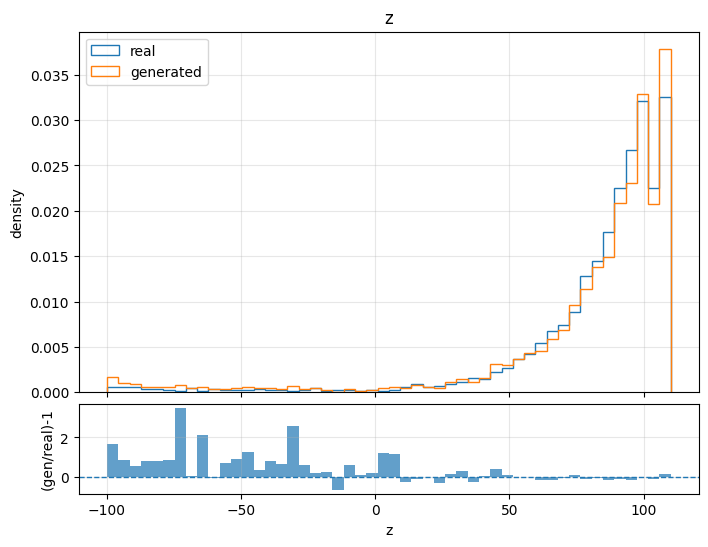

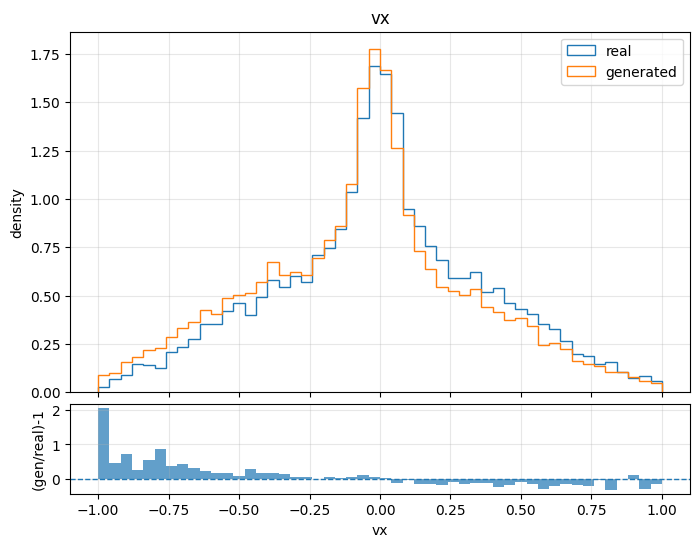

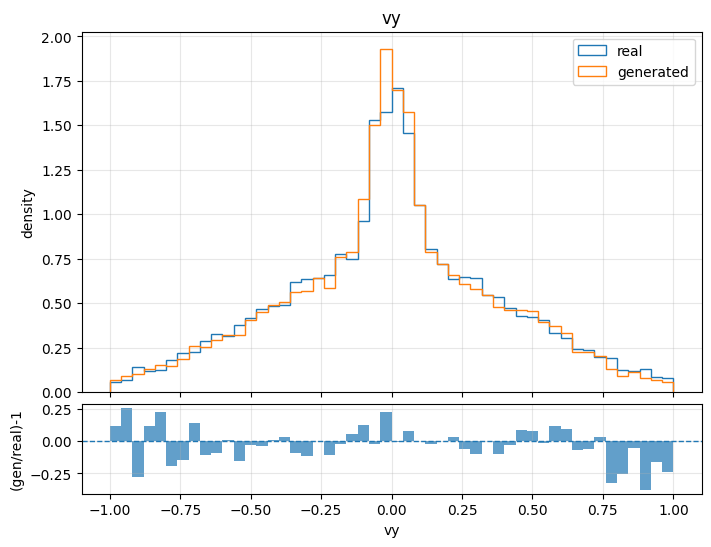

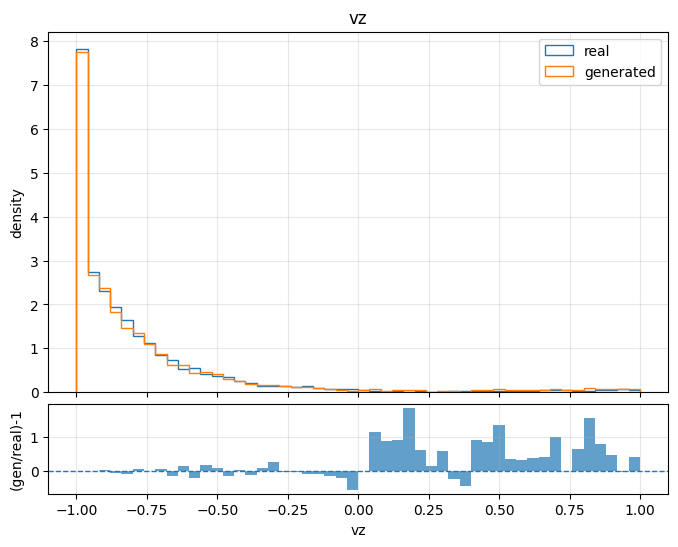


--- RANGE CHECK ---
logE real/gen: -2.922708420954914 4.943072877471457 | -2.7772012 4.8452725
u_v  real/gen: -0.9999958767027343 0.9958781430575513 | -0.9999956112559258 0.9906423632989498

Position:
x real/gen: -104.77028898868913 104.97906084723935 | -104.95983297810574 104.52775731160516
y real/gen: -104.57785490967481 104.75807923797464 | -104.77530484174224 104.98605722468446
z real/gen: -99.84033448808027 109.99898639371551 | -99.86607138287148 109.99898540806973

Direction:
cphi_v real/gen: -0.9999998200597096 0.9999995811741212 | -0.9999998307891894 0.9999993395590688
sphi_v real/gen: -0.9999999348779164 0.9999999087723225 | -0.9999999892367112 0.9999999920973888
vx real/gen: -0.992274622398623 0.9981249235558899 | -0.9983033717970192 0.9975396054543795
vy real/gen: -0.9998864973975311 0.9999962263468651 | -0.9996119941025082 0.99994389113406
vz real/gen: -0.9999958767027343 0.9958781430575513 | -0.9999956112549258 0.9906423632979776

--- COS/SIN NORM CHECK ---
phi_r real/gen

In [26]:
magi.set_plot_theme("light")

# ==========================================================
# Energy
# ==========================================================

magi.compare_hist_with_residuals(
    real_phys["logE_real"],
    gen_phys["logE_gen"],
    "log10(E)",
    bins=400,
    #savepath=f"./Plots/v0_8_energy_distribution_{SOURCE}.png",
    #dpi=300,
    show=True,
)

# ==========================================================
# Quantile-space variables, model native space
# ==========================================================

for key, label in [
    ("u_r_q", "u_r_q"),
    ("u_v_q", "u_v_q"),
    ("phi_r_q", "phi_r_q"),
    ("phi_v_q", "phi_v_q"),
]:
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Physical spherical variables
# ==========================================================

for key, label in [
    ("u_r", "u_r = cos(theta_r)"),
    ("u_v", "u_v = cos(theta_v)"),
]:
    plot_range = (
        min(real_phys[f"{key}_real"].min(), gen_phys[f"{key}_gen"].min()),
        max(real_phys[f"{key}_real"].max(), gen_phys[f"{key}_gen"].max()),
    )
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        range_=plot_range,
        ratio_clip=5,
        bins=50,
    )

# ==========================================================
# Physical angular variables
# ==========================================================

for key, label in [("phi_r", "phi_r"), ("phi_v", "phi_v")]:
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"],
        gen_phys[f"{key}_gen"],
        label,
        range_=(-np.pi, np.pi),
        ratio_clip=5,
        bins=80,
    )

# ==========================================================
# Cartesian position and direction
# ==========================================================

for key in ["x", "y", "z"]:
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"], gen_phys[f"{key}_gen"], key, ratio_clip=5, bins=50,
    )

for key in ["vx", "vy", "vz"]:
    magi.compare_hist_with_residuals(
        real_phys[f"{key}_real"], gen_phys[f"{key}_gen"], key,
        range_=(-1, 1), ratio_clip=5, bins=50,
    )

# ==========================================================
# Final reports
# ==========================================================

magi.report_final_ranges(real_phys, gen_phys)
magi.report_norm_checks(real_phys, gen_phys)

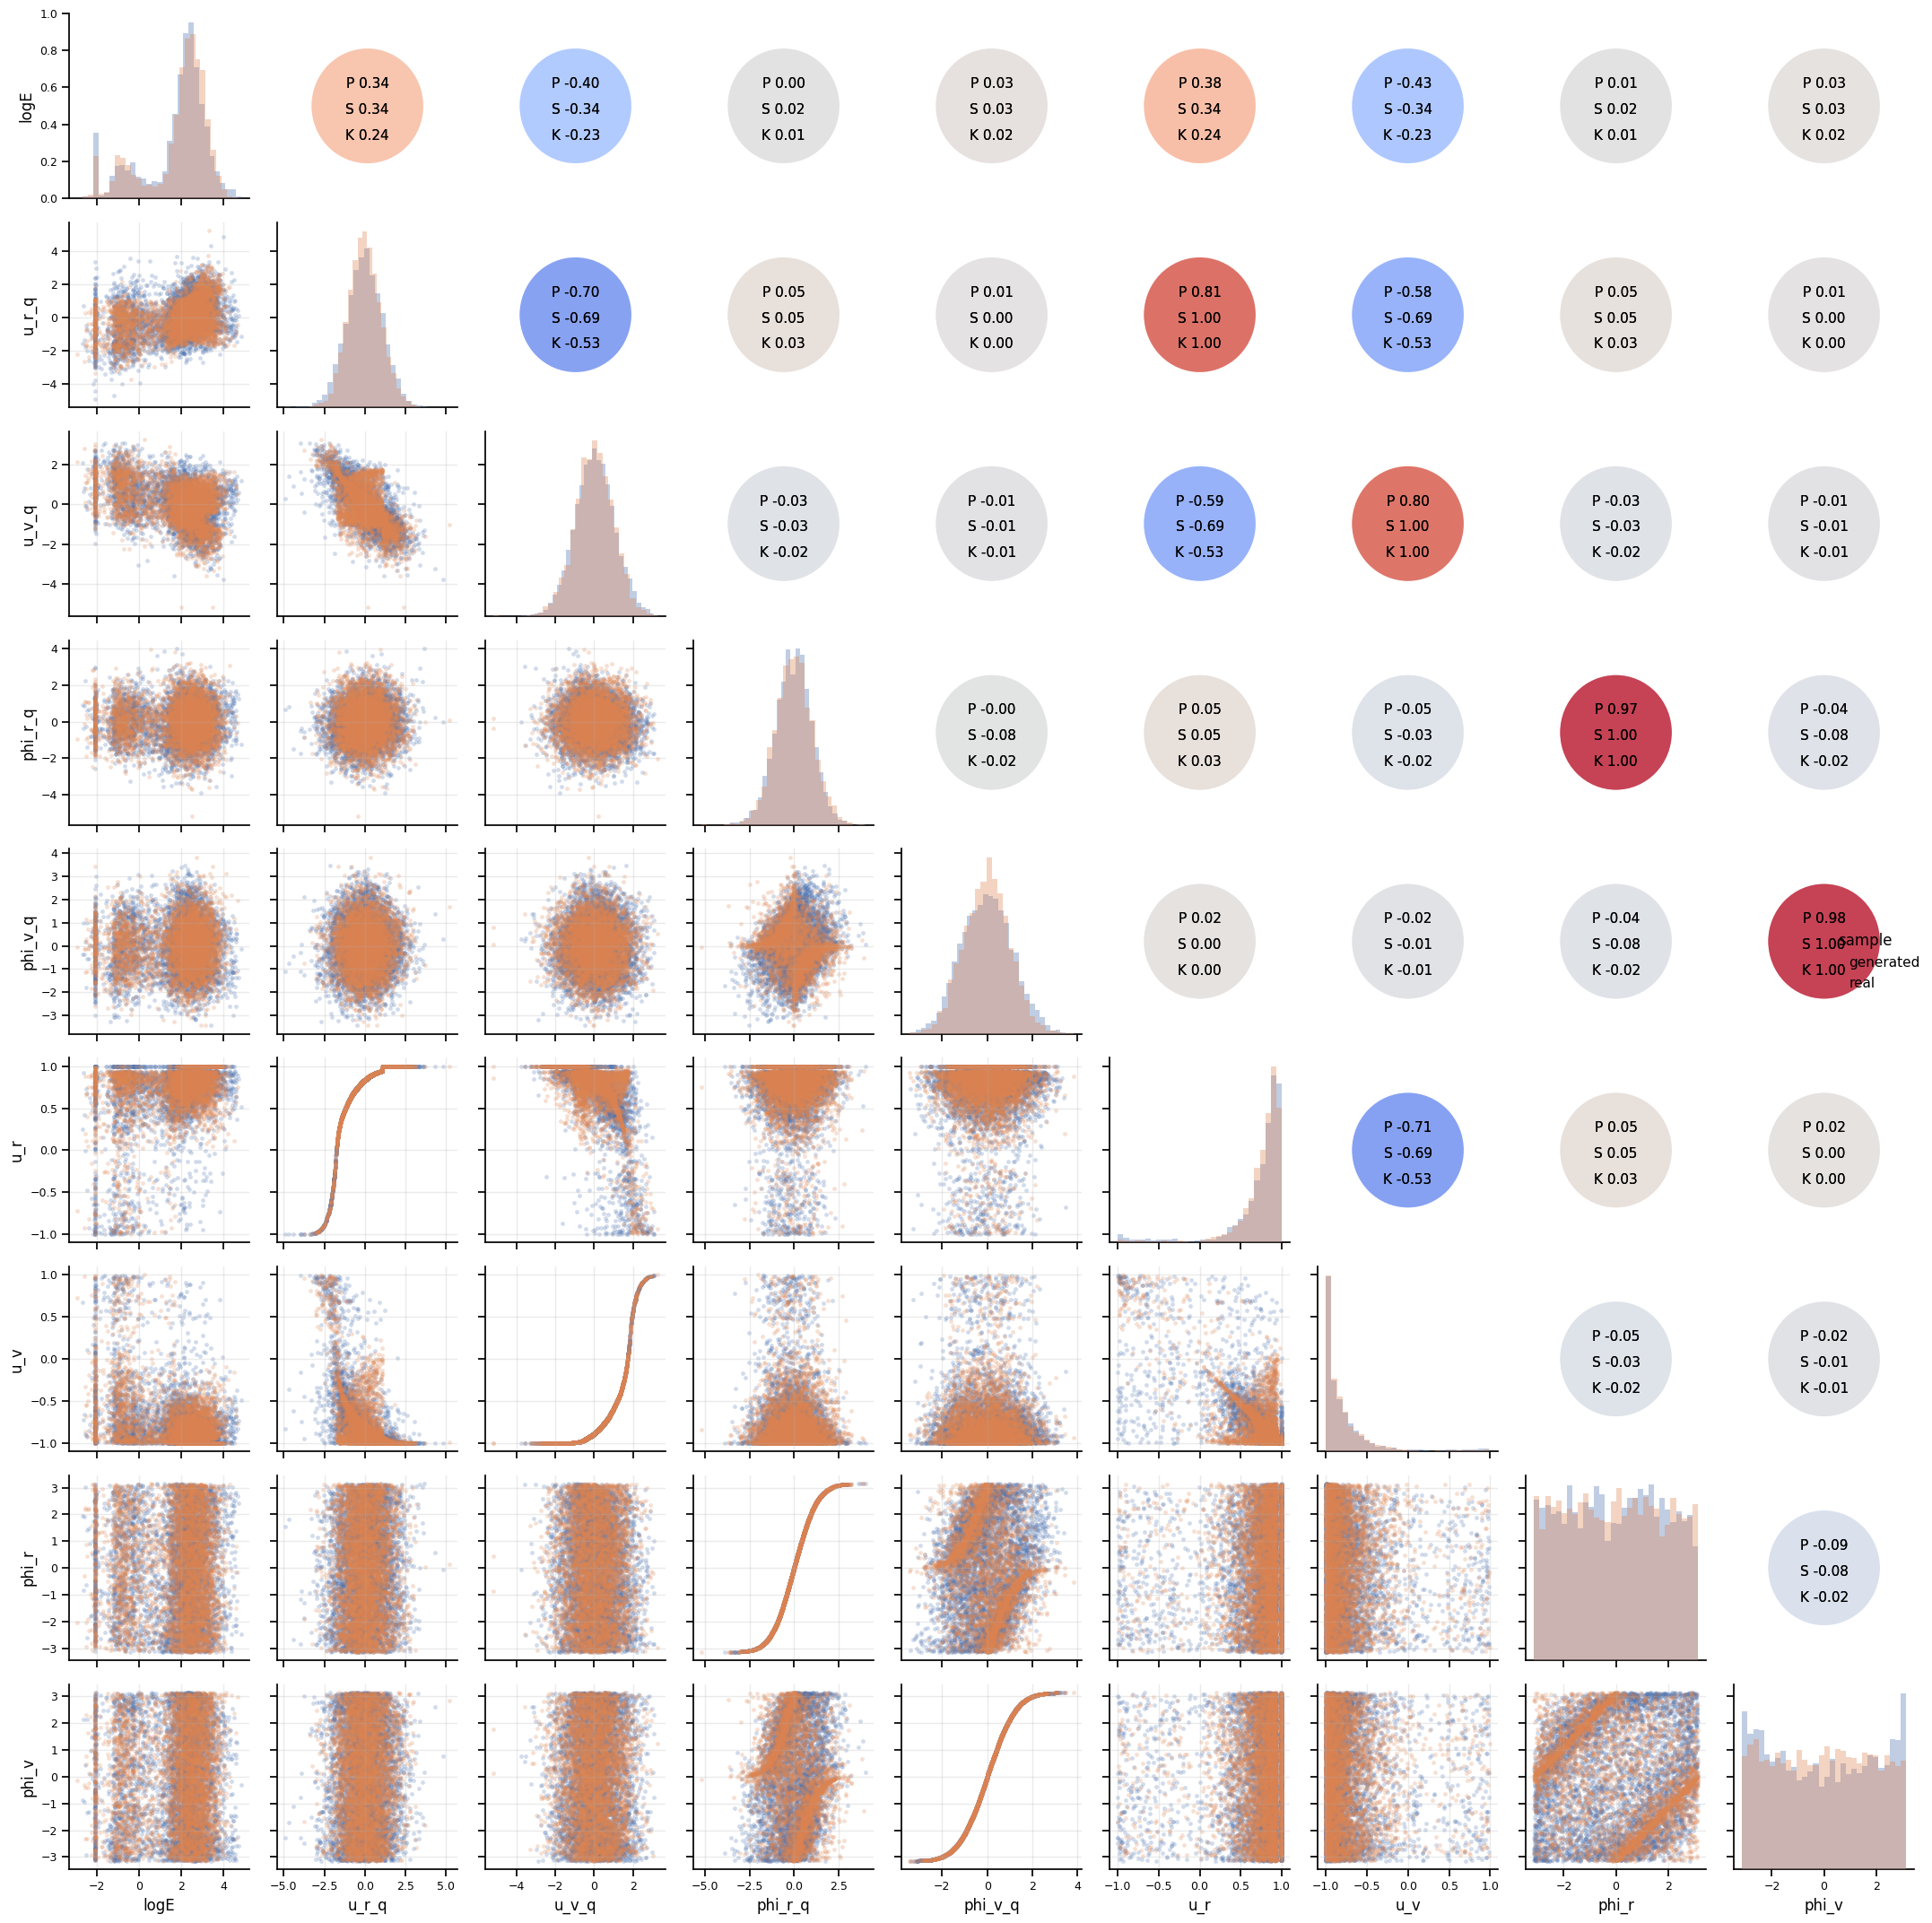

In [27]:
# ==========================================================
# Joint structure: pairgrid over model-native + physical variables
# ==========================================================

df_real_plot, df_gen_plot, df_compare = magi.build_real_generated_featureframes(
    real_phys,
    gen_phys,
)

corr_cols_compare = [
    "logE",
    "u_r_q", "u_v_q", "phi_r_q", "phi_v_q",
    "u_r", "u_v", "phi_r", "phi_v",
]

magi.plot_pairgrid_physics(
    df_compare,
    cols=corr_cols_compare,
    class_col="sample",
    sample_size=10000,
    lower_mode="scatter",
    bins=30,
    contour_levels=8,
    figsize_scale=2.4,
)

plt.show()

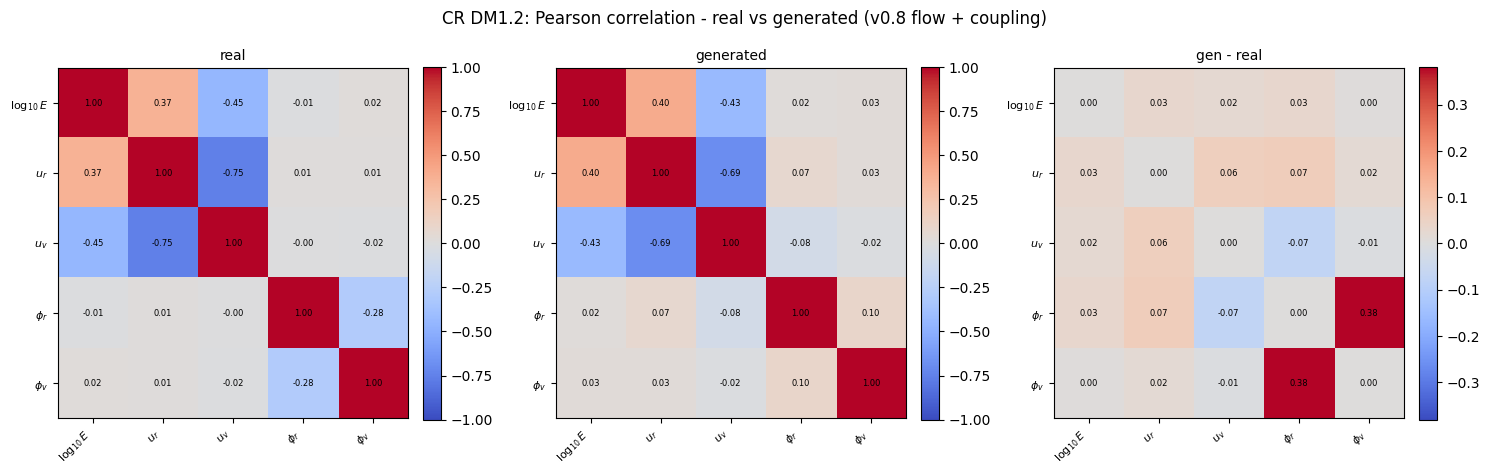

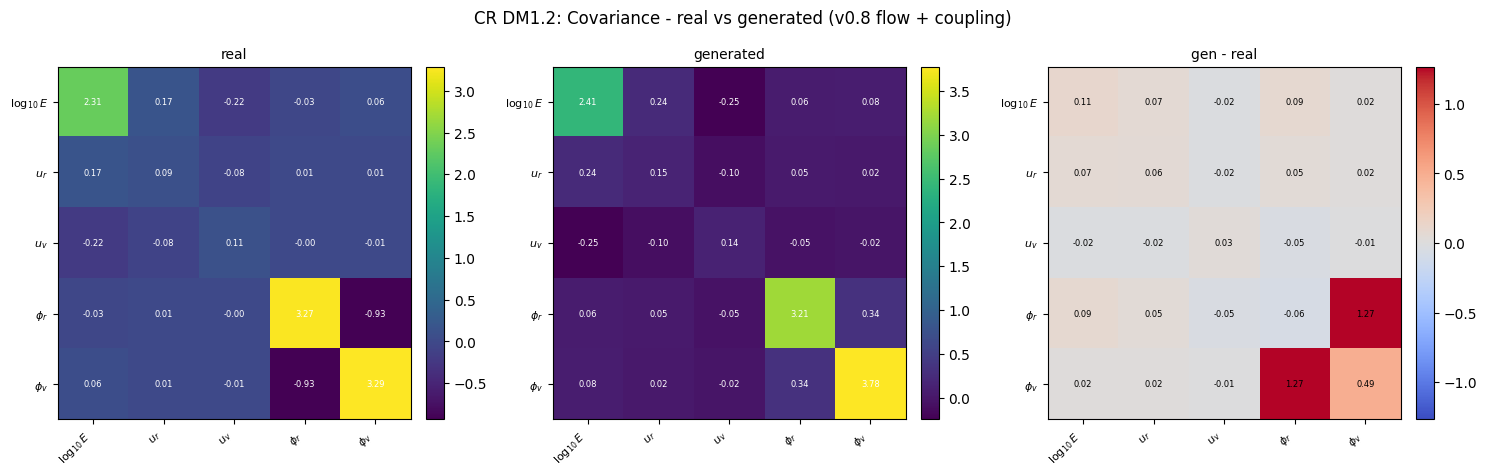

largest correlation residual: phi_r <-> phi_v  real -0.284 -> gen +0.096  (delta +0.381)


In [28]:
# ==========================================================
# Covariance / correlation triptychs: real | generated | (gen - real)
#
# This is the acceptance test for the learnable coupling prior. The number to
# watch is the energy<->geometry block: with prior="gaussian" the logE rows go
# flat at generation even though the model fits them in training (aggregated-
# posterior/prior mismatch). Target: every residual within +/-0.05.
# Same figures as tools/plot_v0_8_real_corr.py.
# ==========================================================

VARS = ["logE", "u_r", "u_v", "phi_r", "phi_v"]
LABELS = [r"$\log_{10}E$", r"$u_r$", r"$u_v$", r"$\phi_r$", r"$\phi_v$"]


def plot_matrix_triptych(df_real, df_gen, name, kind="corr", savepath=None):
    Xr = df_real[VARS].to_numpy()
    Xg = df_gen[VARS].to_numpy()

    if kind == "cov":
        Mr, Mg = np.cov(Xr, rowvar=False), np.cov(Xg, rowvar=False)
        cmap, title, vlim = "viridis", "Covariance", None
    else:
        Mr, Mg = np.corrcoef(Xr, rowvar=False), np.corrcoef(Xg, rowvar=False)
        cmap, title, vlim = "coolwarm", "Pearson correlation", (-1, 1)

    diff = Mg - Mr
    dmax = np.abs(diff).max() or 1.0

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    panels = [("real", Mr, cmap, vlim),
              ("generated", Mg, cmap, vlim),
              ("gen - real", diff, "coolwarm", (-dmax, dmax))]

    for ax, (ttl, M, cm, vl) in zip(axes, panels):
        kw = {} if vl is None else {"vmin": vl[0], "vmax": vl[1]}
        im = ax.imshow(M, cmap=cm, **kw)
        ax.set_xticks(range(len(VARS)))
        ax.set_xticklabels(LABELS, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(VARS)))
        ax.set_yticklabels(LABELS, fontsize=8)
        ax.set_title(ttl, fontsize=10)
        for a in range(len(VARS)):
            for b in range(len(VARS)):
                ax.text(b, a, f"{M[a, b]:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if cm == "viridis" else "black")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"{name}: {title} - real vs generated (v0.8 flow + coupling)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    if savepath:
        fig.savefig(savepath, dpi=130, bbox_inches="tight")
    plt.show()
    return Mr, Mg


corr_r, corr_g = plot_matrix_triptych(
    df_real_plot, df_gen_plot, SOURCE, "corr",
    savepath=f"./Plots/v0_8_real_{SOURCE}_corr.png")

cov_r, cov_g = plot_matrix_triptych(
    df_real_plot, df_gen_plot, SOURCE, "cov",
    savepath=f"./Plots/v0_8_real_{SOURCE}_cov.png")

worst = np.abs(corr_g - corr_r)
i, j = np.unravel_index(np.argmax(worst), worst.shape)
print(f"largest correlation residual: {VARS[i]} <-> {VARS[j]}  "
      f"real {corr_r[i, j]:+.3f} -> gen {corr_g[i, j]:+.3f}  "
      f"(delta {corr_g[i, j] - corr_r[i, j]:+.3f})")

### Acceptance

The same thresholds `tools/acceptance_v0_8.py` applies to a checkpoint, so a
notebook run and an unattended run are graded identically:

| check | threshold |
|---|---|
| per-line recovery | 0.8 – 1.2 |
| near-line continuum ratio | 0.85 – 1.15 |
| Wasserstein on log10(E) | ≤ 0.05 |
| max coupling residual | ≤ 0.05 |

For the unattended equivalent over both sources:

```
python tools/acceptance_v0_8.py --sources CR Small --json logs/acceptance.json
```

## Saving Model

`model.to_generation_config()` is the important part: it captures everything the
loader needs to rebuild this exact architecture (line positions, continuum mode,
flow hyperparameters **and the CDF warp knots**, prior type, focal gamma, per-line
widths and their trainability). That is why the reload cell above only has to read
the JSON back instead of retyping a config dict like v0.7.2 did.

In [29]:
# ==========================================================
# Final model saving with metadata - v0.8
# ==========================================================

save_dir = f"trained_models/v0_8_1_{SOURCE}"
model_name = f"mix_{SOURCE}"

save_info = magi.save_final_trained_model(
    model=model,
    save_dir=save_dir,
    model_name=model_name,
    history=history,
    model_config=model.to_generation_config(),   # self-describing, authoritative
    preprocessing_metadata=preprocessing_metadata,
    training_metadata={
        "source": SOURCE,
        "epochs_requested": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "seed": 42,
        "geometry_mode": "quantile_u_r_u_v_phi_r_phi_v",
        "energy_transform": "log10",
        "device": "cpu",
    },
    callbacks=callbacks,
    notes=(
        "v0.8 mixture energy head: conditional RQS-flow continuum (24 bins, 3 "
        "transforms) with a CDF pre-warp, plus fixed-position Gaussian lines with "
        "widths pinned to the X-IFU 4 eV FWHM resolution. Energy head and gate "
        "conditioned on the latent z (energy_flow_condition='z_cond') with a "
        "learnable conditional coupling prior p(z|cond), so energy<->geometry "
        "coupling survives generation. Gate supervised with a focal-weighted "
        "auxiliary CE (w_gate_aux=2.0, gamma=2.0) against the ~99% continuum "
        "majority. Geometry unchanged from v0.7.2 (quantile u_r/u_v/phi_r/phi_v)."
    ),
)

import joblib

joblib.dump(
    quantile_transformers,
    f"{save_dir}/{model_name}_quantile_transformers.joblib",
)

print("saved ->", save_dir)

Saved final trained model to: trained_models/v0_8_1_CR DM1.2
saved -> trained_models/v0_8_1_CR DM1.2


In [30]:
magi.save_detector_table(
    gen_phys,
    filepath=f"./checkpoints/generated_particles/v0_8_1_{SOURCE}_generated.txt",
)

Saved detector table to: ./checkpoints/generated_particles/v0_8_1_CR DM1.2_generated.txt
Rows saved: 10882
Columns: ['ParticleName', 'Energy', 'X', 'Y', 'Z', 'Vx', 'Vy', 'Vz']


,ParticleName,Energy,X,Y,Z,Vx,Vy,Vz
0,mu-,519.433472,-2.790442,-43.540285,100.506319,-0.152006,-0.031393,-0.987881
1,mu-,163.615524,-80.314704,-4.508870,72.484949,0.196099,-0.642159,-0.741064
2,mu-,15252.130859,-4.105863,-7.679438,109.638273,0.057344,0.036636,-0.997682
3,e-,0.007985,8.474487,-6.713915,109.441881,0.554956,0.551568,-0.622733
4,mu-,335.934174,12.614522,0.142991,109.239404,-0.012747,0.207384,-0.978177
...,...,...,...,...,...,...,...,...
10877,mu-,990.086060,-26.580792,46.436426,95.344451,-0.095373,0.056827,-0.993818
10878,mu-,49.142529,47.024924,-46.696613,86.443741,0.112206,-0.652121,-0.749765
10879,mu-,414.004303,38.881970,82.963311,56.286270,0.518616,0.695114,-0.497849
10880,mu-,265.551086,-32.876414,42.490678,95.214653,0.140054,-0.433491,-0.890208


# Generating Input Files for Geant4

`magi.generate_detector_table_to_file` now handles the v0.8 mixture energy head:
the fitted geometry transformers travel in `geometry_metadata` and the energy
transform in `energy_metadata` (`energy_head_mode="mixture"`,
`energy_transform="log10"` — the head emits `y = log10(E)`, so there are no
energy bins). The writer chunks generation to disk, drops neutrinos, and keeps
generating until `n_events` transportable particles have been written.

In [31]:
# Geant4-format export for the v0.8 mixture head.
# Columns: ParticleName Energy X Y Z Vx Vy Vz  (same schema as v0.7.2's export).
#
# geometry_metadata carries only JSON-safe descriptors, so it is merged with the
# fitted QuantileTransformer objects that reconstruction actually needs.

# magi.generate_detector_table_to_file(
#     model=model,
#     filepath=f"./generated/geant_input_v0_8_{SOURCE}_1M.txt",
#     n_events=1_000_000,
#     type_probs=type_probs,
#     n_types=n_types,
#     idx_to_type=idx_to_type,
#     # v0.8: no categorical energy bins - the mixture head returns y = log10(E)
#     energy_bins=None,
#     energy_metadata={
#         "energy_head_mode": "mixture",
#         "energy_transform": "log10",
#     },
#     geometry_metadata={**geometry_metadata, **quantile_transformers},
#     center=center,
#     radius=R,
#     chunk_size=100_000,
#     output_format="text",
# )

In [32]:
# Read back and eyeball the exported file
# cols_no_event_id = ["ParticleName", "Energy", "X", "Y", "Z", "Vx", "Vy", "Vz"]
# test_df = magi.load_detector_table(
#     f"./generated/geant_input_v0_8_{SOURCE}_1M.txt",
#     columns=cols_no_event_id,
#     drop_event_id=False,
# )
# test_df.head()

## Notes on this run

**Configuration.** Flow continuum (24 bins, 3 transforms) + CDF pre-warp; fixed
lines pinned to 4 eV FWHM at **EADL** energies; `energy_flow_condition="z_cond"`;
`prior="coupling"`; gate targets with a **resolution** bandwidth; `w_gate_aux=2.0`,
`gate_focal_gamma=1.0`; 40 epochs on CPU (~48 min CR, ~33 min Small).

**What v0.8.1 fixed, and what it did not touch.** A–D above were all measurement or
supervision defects; the model architecture is unchanged. The two results that were
never affected by them stand: the **coupling prior** (all cross-correlations within
±0.04 CR / ±0.03 Small) and the **Cycle-1 continuum** work (CR muon notch, Small
low-energy tail).

**Still open.**
- Per-line `gate_class_weights`, if the acceptance report still shows a heterogeneous
  per-line gap after the bandwidth fix — with a two-sided clip.
- CR's low-energy Compton edge is still slightly rounded: `continuum_flow_bins`
  24 → 32, or a non-uniform quantile grid in `fit_cdf_warp_knots` concentrating knots
  across the edge.
- Multi-seed error bars (`--seed` on the run and validation tools), the
  train↔generate config-match guard, and the defaults flip — see
  `docs/v0.8.1_improvement_plan.md` §3–§5.

**Escape peaks.** Requested and implemented as candidates
(`--escape-peaks` in `tools/build_candidate_lines_from_geant4.py`, derived from the
detector volumes' materials in the GDML: Au absorber, Si plate and CryoAC, Ge
thermistor, Cu clamps). All 358 candidates were audited against the real spectra and
**none is present** — expected, since this training data is the spectrum of particles
*crossing* a virtual sphere, not energy *deposited* in the detector, and an escape
peak is a deposited-energy artifact. The escaping fluorescence photon appears in this
data as its own line, which is already modelled. Documented as a null result in
`docs/v0.8.1_line_truth.md` §5.

## Appendix — Flow vs Gaussian continuum (synthetic demonstration)

This section is a **self-contained synthetic demo** of the v0.8 energy head's
continuum term. It reproduces CryoSphere-Small's pathology (a single sharp
continuum peak + a sparse low-energy tail + two closely-spaced lines) and
trains the **same** model twice, changing only the continuum:

- `continuum_mode="gaussian"` — the K=1 parametric-Gaussian continuum baseline.
- `continuum_mode="flow"` — the conditional rational-quadratic-spline flow
  continuum (`core/flows.py`), here with `energy_flow_condition="cond"` and the
  line width pinned to the injected resolution.

The plot below overlays the real spectrum (grey) with each model's generated
spectrum. The Gaussian continuum cannot be both sharp at the peak and near-zero
in the empty high-energy region, so it smears into a broad hump; the flow
tracks the real shape across the peak, the sparse tail, the line spike, and the
empty high-E cutoff.

**Caveat (important):** this demo uses *noise* geometry, so it isolates the
continuum-shape question and does **not** exercise the energy<->geometry
coupling. On real data the energy head must condition on the latent `z`
(`energy_flow_condition="z_cond"`, as in the training section above) to keep that
coupling — which re-introduces the aggregated-posterior/prior mismatch and needs
the **learnable prior** before generation is faithful. See
`docs/v0.8_learnable_prior_plan.md`. So: this figure demonstrates the flow's
continuum *shape capacity*, not a finished real-data result.

The full stress tests that gate each development cycle live in
`tools/synthetic_stress_test_small_singlepeak.py` (single peak, `--sparse-tail`)
and `tools/synthetic_stress_test_cr_multimodal.py` (multimodal + rare line
cluster, `--gate-focal-gamma`).

In [ ]:
# Self-contained synthetic demo (no real data needed). Curtailed to EPOCHS=30
# for the full-notebook run (it is an illustrative appendix, not the real
# result); raise it for a cleaner figure.
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
import magi

EPOCHS_DEMO = 30
rng = np.random.default_rng(42)

# --- synthetic Small-like spectrum: sharp peak + sparse tail + 2 close lines
N_TOTAL, LINE_FRAC, N_LINES_DEMO = 30_000, 0.03, 2
cont_w = np.array([0.90, 0.10]); cont_w = cont_w / cont_w.sum() * (1 - LINE_FRAC)
n_lines = int(round(N_TOTAL * LINE_FRAC)); n_cont = N_TOTAL - n_lines
n_peak = int(round(n_cont * cont_w[0] / (1 - LINE_FRAC))); n_tail = n_cont - n_peak
E_peak = 10.0 ** rng.normal(-0.60, 0.20, n_peak)
E_tail = 10.0 ** rng.normal(-2.30, 0.60, n_tail)
line_y = np.array([-2.30, -2.268]); line_mev = 10.0 ** line_y; sig_y = 0.015
per = [n_lines // N_LINES_DEMO] * (N_LINES_DEMO - 1) + [n_lines - (n_lines // N_LINES_DEMO) * (N_LINES_DEMO - 1)]
E_lines = np.concatenate([10.0 ** rng.normal(y0, sig_y, k) for y0, k in zip(line_y, per)])
E_demo = np.concatenate([E_peak, E_tail, E_lines]); rng.shuffle(E_demo)

bins_demo = magi.build_energy_bins(E_demo, mode="log_fixed_count", n_bins=256, min_counts=20)
matched_demo = [{"label": f"line_{i}", "origin": "synthetic",
                 "candidate_energy_mev": float(e), "count": int(c)}
                for i, (e, c) in enumerate(zip(line_mev, per))]
gate_t = magi.build_gate_targets(E_demo, bins_demo, matched_demo)
energy_y_demo = np.log10(E_demo).astype(np.float32); n = E_demo.size
noise = lambda: rng.normal(0, 1, n).astype(np.float32)
y_cont = np.concatenate([noise()[:, None], noise()[:, None], noise()[:, None],
                         noise()[:, None], energy_y_demo[:, None], gate_t.astype(np.float32)], 1)
cond_demo = np.ones((n, 1), np.float32)
ds = tf.data.Dataset.from_tensor_slices(
        ((y_cont, np.zeros(n, np.int32), cond_demo), np.zeros((n, 1), np.float32))
     ).shuffle(n, seed=42).batch(512)

def train_and_gen(**extra):
    m = magi.CVAE_MixEnergy_ContPhi_TaskAdaptive(
            n_types=1, line_positions_y=line_y.astype(np.float32),
            latent_dim=8, hidden=(128, 128, 64), beta=0.2, **extra)
    magi.compile_model(m, learning_rate=2e-4)
    m.fit(ds, epochs=EPOCHS_DEMO, verbose=0)
    return 10.0 ** m.generate(tf.constant(cond_demo), n)["energy_y"].numpy()

E_gauss = train_and_gen()
E_flow  = train_and_gen(continuum_mode="flow", energy_flow_condition="cond",
                        continuum_flow_y_mean=float(energy_y_demo.mean()),
                        continuum_flow_y_scale=float(energy_y_demo.std()),
                        line_logsigma_init=float(np.log(sig_y)),
                        line_logsigma_trainable=False)

# --- plot
hb = np.linspace(-3.6, 1.2, 120); rl = np.log10(E_demo)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True, sharey=True)
for a, Eg, ttl, c in [(ax[0], E_gauss, "Gaussian continuum (K=1 baseline)", "#d1495b"),
                      (ax[1], E_flow, "Flow continuum (new)", "#2e86ab")]:
    a.hist(rl, hb, histtype="stepfilled", color="0.75", edgecolor="0.5", label="real", log=True)
    a.hist(np.log10(Eg), hb, histtype="step", color=c, lw=2, label="generated", log=True)
    for ly in line_y: a.axvline(ly, color="0.3", ls=":", lw=1)
    a.axvspan(-0.8, -0.4, color="orange", alpha=0.10)
    a.set_title(ttl); a.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{MeV})$")
    a.legend(loc="upper left", frameon=False); a.grid(alpha=0.2)
ax[0].set_ylabel("counts / bin")
fig.suptitle("v0.8 energy head on synthetic Small-like spectrum "
             "(shaded = true peak core; dotted = line positions)")
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()